<a href="https://colab.research.google.com/github/sungfeliks/Lightweight-Mixture-of-Experts-with-Knowledge-Distillation-Vision-Language-Model/blob/main/06_efficiency_and_statistical_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PREPARATION**

## **Mount Google Drive**

In [1]:
from google.colab import drive

drive.mount(
    "/content/drive"
)

Mounted at /content/drive


## **Installing the profiling library**

In [2]:
!pip install -q thop

## **Import Library**

In [3]:
import gc
import json
import math
import os
import random
import statistics
import time

from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from thop import profile
from torchvision.models import (
    MobileNet_V3_Small_Weights,
    mobilenet_v3_small,
)

## **Seed and device**

In [4]:
PROFILING_SEED = 42


def set_profiling_seed(
    seed: int,
) -> None:
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


set_profiling_seed(
    PROFILING_SEED
)


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

USE_AMP = (
    DEVICE.type == "cuda"
)


print(
    "Device:",
    DEVICE,
)

print(
    "AMP:",
    USE_AMP,
)

print(
    "PyTorch version:",
    torch.__version__,
)


if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )

    print(
        "CUDA version:",
        torch.version.cuda,
    )

    print(
        "GPU capability:",
        torch.cuda.get_device_capability(0),
    )

    print(
        "Total GPU memory:",
        f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB",
    )

Device: cuda
AMP: True
PyTorch version: 2.11.0+cu128
GPU: Tesla T4
CUDA version: 12.8
GPU capability: (7, 5)
Total GPU memory: 14.56 GB


## **Output and checkpoint directory**

In [5]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Research"
)

OUTPUT_ROOT = (
    PROJECT_ROOT
    / "outputs"
)

PROFILING_OUTPUT_DIR = (
    OUTPUT_ROOT
    / "efficiency_and_statistical_comparison"
)

PROFILING_TABLE_DIR = (
    PROFILING_OUTPUT_DIR
    / "tables"
)

PROFILING_CHECKPOINT_DIR = (
    PROFILING_OUTPUT_DIR
    / "deployable_checkpoints"
)

PROFILING_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PROFILING_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PROFILING_CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


BASELINE_OUTPUT_DIR = (
    OUTPUT_ROOT
    / "student_mobilenetv3_small_baseline"
)

MOE_OUTPUT_DIR = (
    OUTPUT_ROOT
    / "student_mobilenetv3_small_sparse_top2_moe"
)

KD_OUTPUT_DIR = (
    OUTPUT_ROOT
    / "student_mobilenetv3_small_sparse_top2_moe_kd"
)


print(
    "Output root:",
    OUTPUT_ROOT,
)

print(
    "Profiling output:",
    PROFILING_OUTPUT_DIR,
)

Output root: /content/drive/MyDrive/Research/outputs
Profiling output: /content/drive/MyDrive/Research/outputs/efficiency_and_statistical_comparison


## **Checkpoint search function**

In [6]:
def find_first_checkpoint(
    candidate_paths,
    search_directory,
    search_patterns,
):
    for candidate_path in candidate_paths:
        candidate_path = Path(
            candidate_path
        )

        if candidate_path.exists():
            return candidate_path


    discovered_paths = []

    if Path(
        search_directory
    ).exists():
        for pattern in search_patterns:
            discovered_paths.extend(
                Path(
                    search_directory
                ).rglob(
                    pattern
                )
            )


    discovered_paths = sorted(
        {
            path
            for path in discovered_paths
            if path.is_file()
        },
        key=lambda path: (
            len(str(path)),
            str(path),
        ),
    )


    if not discovered_paths:
        raise FileNotFoundError(
            "Checkpoint was not found in "
            f"{search_directory}. "
            f"Patterns: {search_patterns}"
        )


    return discovered_paths[0]

In [7]:
BASELINE_CHECKPOINT_PATH = (
    find_first_checkpoint(
        candidate_paths=[
            (
                BASELINE_OUTPUT_DIR
                / "checkpoints"
                / "mobilenetv3_small_baseline_best.pt"
            ),
            (
                BASELINE_OUTPUT_DIR
                / "checkpoints"
                / "mobilenetv3_small_baseline_best.pth"
            ),
        ],
        search_directory=(
            BASELINE_OUTPUT_DIR
        ),
        search_patterns=[
            "*baseline*best*.pt",
            "*baseline*best*.pth",
        ],
    )
)


MOE_CHECKPOINT_PATH = (
    find_first_checkpoint(
        candidate_paths=[
            (
                MOE_OUTPUT_DIR
                / "checkpoints"
                / "mobilenetv3_small_sparse_top2_moe_best.pt"
            ),
        ],
        search_directory=(
            MOE_OUTPUT_DIR
        ),
        search_patterns=[
            "*sparse*moe*best*.pt",
            "*moe*best*.pth",
        ],
    )
)


KD_DEPLOYABLE_CHECKPOINT_PATH = (
    find_first_checkpoint(
        candidate_paths=[
            (
                KD_OUTPUT_DIR
                / "checkpoints"
                / "mobilenetv3_small_sparse_top2_moe_kd_deployable.pt"
            ),
        ],
        search_directory=(
            KD_OUTPUT_DIR
        ),
        search_patterns=[
            "*kd*deployable*.pt",
            "*kd*deployable*.pth",
        ],
    )
)


print(
    "Baseline checkpoint:",
    BASELINE_CHECKPOINT_PATH,
)

print(
    "MoE checkpoint:",
    MOE_CHECKPOINT_PATH,
)

print(
    "KD deployable checkpoint:",
    KD_DEPLOYABLE_CHECKPOINT_PATH,
)


assert (
    BASELINE_CHECKPOINT_PATH.exists()
)

assert (
    MOE_CHECKPOINT_PATH.exists()
)

assert (
    KD_DEPLOYABLE_CHECKPOINT_PATH.exists()
)

Baseline checkpoint: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_baseline/checkpoints/mobilenetv3_small_baseline_best.pt
MoE checkpoint: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe/checkpoints/mobilenetv3_small_sparse_top2_moe_best.pt
KD deployable checkpoint: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/checkpoints/mobilenetv3_small_sparse_top2_moe_kd_deployable.pt


# **STUDENT MODELS DEFINITION**

## **Checkpoint function**

In [8]:
def extract_model_state_dict(
    checkpoint,
):
    if not isinstance(
        checkpoint,
        dict,
    ):
        raise TypeError(
            "Checkpoint must be a dictionary."
        )


    for state_key in [
        "model_state_dict",
        "state_dict",
        "model",
    ]:
        if (
            state_key in checkpoint
            and isinstance(
                checkpoint[state_key],
                dict,
            )
        ):
            state_dict = checkpoint[
                state_key
            ]

            break

    else:
        state_dict = checkpoint


    state_dict = dict(
        state_dict
    )


    for removable_prefix in [
        "module.",
        "model.",
    ]:
        if (
            len(state_dict) > 0
            and all(
                parameter_name.startswith(
                    removable_prefix
                )
                for parameter_name
                in state_dict.keys()
            )
        ):
            state_dict = {
                parameter_name[
                    len(
                        removable_prefix
                    ):
                ]: parameter_value
                for (
                    parameter_name,
                    parameter_value,
                )
                in state_dict.items()
            }


    return state_dict

## **MobileNetV3-Small baseline**

In [9]:
class MobileNetV3SmallBaseline(
    nn.Module
):
    def __init__(
        self,
        head_name: str = "classifier",
    ):
        super().__init__()

        backbone = mobilenet_v3_small(
            weights=None
        )

        self.features = (
            backbone.features
        )

        self.avgpool = (
            nn.AdaptiveAvgPool2d(1)
        )

        self.feature_dim = int(
            backbone.classifier[0]
            .in_features
        )

        self.head_name = (
            head_name
        )

        setattr(
            self,
            self.head_name,
            nn.Linear(
                self.feature_dim,
                1,
            ),
        )

    def forward(
        self,
        images,
        return_features: bool = False,
    ):
        raw_features = self.features(
            images
        )

        pooled_features = self.avgpool(
            raw_features
        )

        pooled_features = torch.flatten(
            pooled_features,
            start_dim=1,
        )

        classification_head = getattr(
            self,
            self.head_name,
        )

        logits = classification_head(
            pooled_features
        )

        output = {
            "logits": logits,
            "pooled_features": (
                pooled_features
            ),
        }

        if return_features:
            output[
                "raw_features"
            ] = raw_features

        return output

In [10]:
def detect_baseline_head_name(
    state_dict,
):
    preferred_names = [
        "classifier",
        "head",
        "classification_head",
        "fc",
    ]


    for preferred_name in (
        preferred_names
    ):
        weight_key = (
            f"{preferred_name}.weight"
        )

        if (
            weight_key in state_dict
            and tuple(
                state_dict[
                    weight_key
                ].shape
            ) == (1, 576)
        ):
            return preferred_name


    for parameter_name, tensor in (
        state_dict.items()
    ):
        if (
            parameter_name.endswith(
                ".weight"
            )
            and tuple(
                tensor.shape
            ) == (1, 576)
        ):
            detected_name = (
                parameter_name.rsplit(
                    ".",
                    1,
                )[0]
            )

            if "." not in detected_name:
                return detected_name


    raise KeyError(
        "Unable to detect the baseline "
        "classification head."
    )

## **Sparse Top-2 MoE**

In [11]:
class BinaryExpert(
    nn.Module
):
    def __init__(
        self,
        input_dim: int,
        hidden_dim: int = 128,
        dropout: float = 0.2,
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(
                input_dim,
                hidden_dim,
            ),
            nn.Hardswish(),
            nn.Dropout(
                dropout
            ),
            nn.Linear(
                hidden_dim,
                1,
            ),
        )

    def forward(
        self,
        features,
    ):
        return self.network(
            features
        )

In [12]:
class SparseTop2MoEHead(
    nn.Module
):
    def __init__(
        self,
        input_dim: int,
        num_experts: int = 3,
        top_k: int = 2,
        expert_hidden_dim: int = 128,
        router_hidden_dim: int = 128,
        expert_dropout: float = 0.2,
        router_dropout: float = 0.1,
        eps: float = 1e-8,
    ):
        super().__init__()

        if not (
            1 <= top_k <= num_experts
        ):
            raise ValueError(
                "top_k must be between "
                "1 and num_experts."
            )

        self.num_experts = (
            num_experts
        )

        self.top_k = top_k
        self.eps = eps

        self.router = nn.Sequential(
            nn.Linear(
                input_dim,
                router_hidden_dim,
            ),
            nn.Hardswish(),
            nn.Dropout(
                router_dropout
            ),
            nn.Linear(
                router_hidden_dim,
                num_experts,
            ),
        )

        self.experts = nn.ModuleList(
            [
                BinaryExpert(
                    input_dim=input_dim,
                    hidden_dim=(
                        expert_hidden_dim
                    ),
                    dropout=(
                        expert_dropout
                    ),
                )
                for _ in range(
                    num_experts
                )
            ]
        )

    def forward(
        self,
        features,
    ):
        router_logits = self.router(
            features
        )

        router_probabilities = (
            torch.softmax(
                router_logits,
                dim=1,
            )
        )


        (
            topk_probabilities,
            topk_indices,
        ) = torch.topk(
            router_probabilities,
            k=self.top_k,
            dim=1,
        )


        normalized_topk_probabilities = (
            topk_probabilities
            / topk_probabilities.sum(
                dim=1,
                keepdim=True,
            ).clamp_min(
                self.eps
            )
        )


        sparse_gates = torch.zeros_like(
            router_probabilities
        )

        sparse_gates.scatter_(
            dim=1,
            index=topk_indices,
            src=(
                normalized_topk_probabilities
            ),
        )


        expert_logits = torch.cat(
            [
                expert(
                    features
                )
                for expert
                in self.experts
            ],
            dim=1,
        )


        combined_logits = (
            expert_logits
            * sparse_gates
        ).sum(
            dim=1,
            keepdim=True,
        )


        mean_router_probability = (
            router_probabilities.mean(
                dim=0
            )
        )

        balance_loss = (
            self.num_experts
            * torch.sum(
                mean_router_probability
                ** 2
            )
            - 1.0
        )


        hard_assignments = (
            torch.zeros_like(
                router_probabilities
            )
            .scatter(
                dim=1,
                index=topk_indices,
                value=1.0,
            )
        )

        expert_usage = (
            hard_assignments.sum(
                dim=0
            )
            / (
                features.size(0)
                * self.top_k
            )
        )


        router_entropy = (
            -(
                router_probabilities
                * torch.log(
                    router_probabilities
                    .clamp_min(
                        self.eps
                    )
                )
            )
            .sum(dim=1)
            .mean()
            / math.log(
                self.num_experts
            )
        )


        return {
            "logits": (
                combined_logits
            ),
            "expert_logits": (
                expert_logits
            ),
            "router_logits": (
                router_logits
            ),
            "router_probabilities": (
                router_probabilities
            ),
            "sparse_gates": (
                sparse_gates
            ),
            "topk_indices": (
                topk_indices
            ),
            "expert_usage": (
                expert_usage
            ),
            "balance_loss": (
                balance_loss
            ),
            "router_entropy": (
                router_entropy
            ),
        }

In [13]:
class MobileNetV3SmallSparseMoE(
    nn.Module
):
    def __init__(
        self,
        num_experts: int = 3,
        top_k: int = 2,
        expert_hidden_dim: int = 128,
        router_hidden_dim: int = 128,
        expert_dropout: float = 0.2,
        router_dropout: float = 0.1,
    ):
        super().__init__()

        backbone = mobilenet_v3_small(
            weights=None
        )

        self.features = (
            backbone.features
        )

        self.avgpool = (
            nn.AdaptiveAvgPool2d(1)
        )

        self.feature_dim = int(
            backbone.classifier[0]
            .in_features
        )

        self.num_experts = (
            num_experts
        )

        self.top_k = top_k

        self.moe_head = (
            SparseTop2MoEHead(
                input_dim=(
                    self.feature_dim
                ),
                num_experts=(
                    num_experts
                ),
                top_k=top_k,
                expert_hidden_dim=(
                    expert_hidden_dim
                ),
                router_hidden_dim=(
                    router_hidden_dim
                ),
                expert_dropout=(
                    expert_dropout
                ),
                router_dropout=(
                    router_dropout
                ),
            )
        )

    def forward(
        self,
        images,
        return_features: bool = False,
    ):
        raw_features = self.features(
            images
        )

        pooled_features = self.avgpool(
            raw_features
        )

        pooled_features = torch.flatten(
            pooled_features,
            start_dim=1,
        )

        output = self.moe_head(
            pooled_features
        )

        output[
            "pooled_features"
        ] = pooled_features

        if return_features:
            output[
                "raw_features"
            ] = raw_features

        return output

## **Loading the three models**

In [14]:
baseline_checkpoint = torch.load(
    BASELINE_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

moe_checkpoint = torch.load(
    MOE_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

kd_checkpoint = torch.load(
    KD_DEPLOYABLE_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)


baseline_state_dict = (
    extract_model_state_dict(
        baseline_checkpoint
    )
)

moe_state_dict = (
    extract_model_state_dict(
        moe_checkpoint
    )
)

kd_state_dict = (
    extract_model_state_dict(
        kd_checkpoint
    )
)


baseline_head_name = (
    detect_baseline_head_name(
        baseline_state_dict
    )
)


baseline_model = (
    MobileNetV3SmallBaseline(
        head_name=(
            baseline_head_name
        )
    )
)

moe_model = (
    MobileNetV3SmallSparseMoE()
)

kd_deployable_model = (
    MobileNetV3SmallSparseMoE()
)


baseline_model.load_state_dict(
    baseline_state_dict,
    strict=True,
)

moe_model.load_state_dict(
    moe_state_dict,
    strict=True,
)

kd_deployable_model.load_state_dict(
    kd_state_dict,
    strict=True,
)


baseline_model.eval()
moe_model.eval()
kd_deployable_model.eval()


student_models = {
    "MobileNetV3-Small Baseline": (
        baseline_model
    ),
    "Sparse Top-2 MoE": (
        moe_model
    ),
    "Sparse Top-2 MoE + KD": (
        kd_deployable_model
    ),
}


print(
    "Baseline head name:",
    baseline_head_name,
)

for model_name, model in (
    student_models.items()
):
    parameter_count = sum(
        parameter.numel()
        for parameter
        in model.parameters()
    )

    print(
        model_name,
        ":",
        f"{parameter_count:,}",
    )

Baseline head name: classifier
MobileNetV3-Small Baseline : 927,585
Sparse Top-2 MoE : 1,223,206
Sparse Top-2 MoE + KD : 1,223,206


## **Forward sanity check**

In [15]:
STUDENT_INPUT_HEIGHT = 512
STUDENT_INPUT_WIDTH = 320


student_sanity_input = torch.randn(
    2,
    3,
    STUDENT_INPUT_HEIGHT,
    STUDENT_INPUT_WIDTH,
)


with torch.inference_mode():
    for model_name, model in (
        student_models.items()
    ):
        output = model(
            student_sanity_input
        )

        logits = (
            output["logits"]
            if isinstance(
                output,
                dict,
            )
            else output
        )

        print(
            model_name,
            "logits:",
            tuple(
                logits.shape
            ),
        )

        assert (
            logits.shape
            == (2, 1)
        )

        assert torch.isfinite(
            logits
        ).all()


print(
    "All student model forward "
    "checks succeeded."
)

MobileNetV3-Small Baseline logits: (2, 1)
Sparse Top-2 MoE logits: (2, 1)
Sparse Top-2 MoE + KD logits: (2, 1)
All student model forward checks succeeded.


# **STATIC EFFICIENCY METRICS**

## **Wrapper output logit**

In [16]:
class LogitOnlyWrapper(
    nn.Module
):
    def __init__(
        self,
        model,
    ):
        super().__init__()

        self.model = model

    def forward(
        self,
        images,
    ):
        output = self.model(
            images
        )

        if isinstance(
            output,
            dict,
        ):
            return output[
                "logits"
            ]

        return output

## **Model size functions and MAC estimates**

In [17]:
def calculate_parameter_count(
    model,
):
    return int(
        sum(
            parameter.numel()
            for parameter
            in model.parameters()
        )
    )


def calculate_trainable_parameter_count(
    model,
):
    return int(
        sum(
            parameter.numel()
            for parameter
            in model.parameters()
            if parameter.requires_grad
        )
    )


def save_stripped_checkpoint(
    model,
    output_path,
):
    cpu_state_dict = {
        parameter_name: (
            parameter_value
            .detach()
            .cpu()
        )
        for (
            parameter_name,
            parameter_value,
        )
        in model.state_dict().items()
    }

    torch.save(
        {
            "model_state_dict": (
                cpu_state_dict
            ),
        },
        output_path,
    )

    return float(
        output_path.stat().st_size
        / 1024**2
    )


def estimate_macs_and_flops(
    model,
    input_shape,
):
    model = model.cpu()
    model.eval()

    wrapped_model = (
        LogitOnlyWrapper(
            model
        )
    )

    dummy_input = torch.randn(
        *input_shape
    )

    with torch.inference_mode():
        macs, _ = profile(
            wrapped_model,
            inputs=(
                dummy_input,
            ),
            verbose=False,
        )

    estimated_flops = (
        2.0
        * macs
    )

    return (
        float(macs),
        float(estimated_flops),
    )

## **Calculate static metrics**

In [18]:
static_efficiency_records = []


for model_name, model in (
    student_models.items()
):
    parameter_count = (
        calculate_parameter_count(
            model
        )
    )

    trainable_parameter_count = (
        calculate_trainable_parameter_count(
            model
        )
    )


    safe_model_name = (
        model_name
        .lower()
        .replace(
            " ",
            "_",
        )
        .replace(
            "+",
            "plus",
        )
        .replace(
            "-",
            "_",
        )
    )


    stripped_checkpoint_path = (
        PROFILING_CHECKPOINT_DIR
        / (
            f"{safe_model_name}"
            "_deployable.pt"
        )
    )


    stripped_checkpoint_size_mb = (
        save_stripped_checkpoint(
            model=model,
            output_path=(
                stripped_checkpoint_path
            ),
        )
    )


    (
        estimated_macs,
        estimated_flops,
    ) = estimate_macs_and_flops(
        model=model,
        input_shape=(
            1,
            3,
            STUDENT_INPUT_HEIGHT,
            STUDENT_INPUT_WIDTH,
        ),
    )


    static_efficiency_records.append(
        {
            "model": model_name,

            "input_height": (
                STUDENT_INPUT_HEIGHT
            ),

            "input_width": (
                STUDENT_INPUT_WIDTH
            ),

            "parameters": (
                parameter_count
            ),

            "trainable_parameters": (
                trainable_parameter_count
            ),

            "parameter_memory_fp32_mb": (
                parameter_count
                * 4
                / 1024**2
            ),

            "stripped_checkpoint_mb": (
                stripped_checkpoint_size_mb
            ),

            "estimated_macs": (
                estimated_macs
            ),

            "estimated_gmacs": (
                estimated_macs
                / 1e9
            ),

            "estimated_flops": (
                estimated_flops
            ),

            "estimated_gflops": (
                estimated_flops
                / 1e9
            ),

            "stripped_checkpoint_path": str(
                stripped_checkpoint_path
            ),
        }
    )


static_efficiency_dataframe = (
    pd.DataFrame(
        static_efficiency_records
    )
)


display(
    static_efficiency_dataframe[
        [
            "model",
            "parameters",
            "parameter_memory_fp32_mb",
            "stripped_checkpoint_mb",
            "estimated_gmacs",
            "estimated_gflops",
        ]
    ].round(4)
)

,model,parameters,parameter_memory_fp32_mb,stripped_checkpoint_mb,estimated_gmacs,estimated_gflops
0,MobileNetV3-Small Baseline,927585,3.5385,3.6607,0.1977,0.3954
1,Sparse Top-2 MoE,1223206,4.6662,4.7905,0.1980,0.3960
2,Sparse Top-2 MoE + KD,1223206,4.6662,4.7925,0.1980,0.3960


## **Save the static table**

In [19]:
STATIC_EFFICIENCY_PATH = (
    PROFILING_TABLE_DIR
    / "student_static_efficiency.csv"
)


static_efficiency_dataframe.to_csv(
    STATIC_EFFICIENCY_PATH,
    index=False,
)


print(
    "Saved:",
    STATIC_EFFICIENCY_PATH,
)

Saved: /content/drive/MyDrive/Research/outputs/efficiency_and_statistical_comparison/tables/student_static_efficiency.csv


# **DYNAMIC PROFILING**

## **CPU/GPU latency function**

In [20]:
def measure_forward_latency(
    model,
    batch_size: int,
    input_height: int,
    input_width: int,
    device,
    use_amp: bool,
    warmup_iterations: int = 30,
    measured_iterations: int = 100,
):
    model = model.to(
        device
    )

    model.eval()


    dummy_input = torch.randn(
        batch_size,
        3,
        input_height,
        input_width,
        device=device,
    )


    with torch.inference_mode():
        for _ in range(
            warmup_iterations
        ):
            with torch.autocast(
                device_type=(
                    device.type
                ),
                dtype=torch.float16,
                enabled=(
                    use_amp
                    and device.type
                    == "cuda"
                ),
            ):
                _ = model(
                    dummy_input
                )


    if device.type == "cuda":
        torch.cuda.synchronize()

        start_events = [
            torch.cuda.Event(
                enable_timing=True
            )
            for _ in range(
                measured_iterations
            )
        ]

        end_events = [
            torch.cuda.Event(
                enable_timing=True
            )
            for _ in range(
                measured_iterations
            )
        ]


        with torch.inference_mode():
            for iteration_index in range(
                measured_iterations
            ):
                start_events[
                    iteration_index
                ].record()

                with torch.autocast(
                    device_type="cuda",
                    dtype=torch.float16,
                    enabled=use_amp,
                ):
                    _ = model(
                        dummy_input
                    )

                end_events[
                    iteration_index
                ].record()


        torch.cuda.synchronize()


        batch_latency_values_ms = np.asarray(
            [
                start_event.elapsed_time(
                    end_event
                )
                for (
                    start_event,
                    end_event,
                )
                in zip(
                    start_events,
                    end_events,
                )
            ],
            dtype=np.float64,
        )

    else:
        measured_values = []

        with torch.inference_mode():
            for _ in range(
                measured_iterations
            ):
                start_time = (
                    time.perf_counter()
                )

                _ = model(
                    dummy_input
                )

                end_time = (
                    time.perf_counter()
                )

                measured_values.append(
                    (
                        end_time
                        - start_time
                    )
                    * 1000.0
                )

        batch_latency_values_ms = (
            np.asarray(
                measured_values,
                dtype=np.float64,
            )
        )


    median_batch_latency_ms = float(
        np.median(
            batch_latency_values_ms
        )
    )


    result = {
        "batch_size": int(
            batch_size
        ),

        "warmup_iterations": int(
            warmup_iterations
        ),

        "measured_iterations": int(
            measured_iterations
        ),

        "mean_batch_latency_ms": float(
            batch_latency_values_ms.mean()
        ),

        "median_batch_latency_ms": (
            median_batch_latency_ms
        ),

        "std_batch_latency_ms": float(
            batch_latency_values_ms.std(
                ddof=1
            )
        ),

        "p95_batch_latency_ms": float(
            np.percentile(
                batch_latency_values_ms,
                95,
            )
        ),

        "median_latency_per_image_ms": float(
            median_batch_latency_ms
            / batch_size
        ),

        "throughput_images_per_second": float(
            batch_size
            / (
                median_batch_latency_ms
                / 1000.0
            )
        ),
    }


    del dummy_input

    model = model.cpu()

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


    return result

## **Peak GPU Memory Function**

In [21]:
def measure_incremental_peak_memory(
    model,
    batch_size: int,
    input_height: int,
    input_width: int,
    device,
    use_amp: bool,
    iterations: int = 20,
):
    if device.type != "cuda":
        return {
            "base_allocated_mb": (
                float("nan")
            ),
            "peak_allocated_mb": (
                float("nan")
            ),
            "incremental_peak_mb": (
                float("nan")
            ),
        }


    model = model.to(
        device
    )

    model.eval()


    dummy_input = torch.randn(
        batch_size,
        3,
        input_height,
        input_width,
        device=device,
    )


    with torch.inference_mode():
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=use_amp,
        ):
            _ = model(
                dummy_input
            )


    torch.cuda.synchronize()


    base_allocated_bytes = (
        torch.cuda.memory_allocated()
    )


    torch.cuda.reset_peak_memory_stats()


    with torch.inference_mode():
        for _ in range(
            iterations
        ):
            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16,
                enabled=use_amp,
            ):
                _ = model(
                    dummy_input
                )


    torch.cuda.synchronize()


    peak_allocated_bytes = (
        torch.cuda.max_memory_allocated()
    )


    result = {
        "base_allocated_mb": float(
            base_allocated_bytes
            / 1024**2
        ),

        "peak_allocated_mb": float(
            peak_allocated_bytes
            / 1024**2
        ),

        "incremental_peak_mb": float(
            max(
                peak_allocated_bytes
                - base_allocated_bytes,
                0,
            )
            / 1024**2
        ),
    }


    del dummy_input

    model = model.cpu()

    gc.collect()

    torch.cuda.empty_cache()


    return result

## **Run profiling**

In [22]:
PROFILING_BATCH_SIZES = [
    1,
    16,
]

WARMUP_ITERATIONS = 30
MEASURED_ITERATIONS = 100


dynamic_efficiency_records = []


for model_name, model in (
    student_models.items()
):
    print()
    print(
        "=" * 70
    )

    print(
        "Profiling:",
        model_name,
    )

    print(
        "=" * 70
    )


    for batch_size in (
        PROFILING_BATCH_SIZES
    ):
        latency_result = (
            measure_forward_latency(
                model=model,
                batch_size=(
                    batch_size
                ),
                input_height=(
                    STUDENT_INPUT_HEIGHT
                ),
                input_width=(
                    STUDENT_INPUT_WIDTH
                ),
                device=DEVICE,
                use_amp=USE_AMP,
                warmup_iterations=(
                    WARMUP_ITERATIONS
                ),
                measured_iterations=(
                    MEASURED_ITERATIONS
                ),
            )
        )


        memory_result = (
            measure_incremental_peak_memory(
                model=model,
                batch_size=(
                    batch_size
                ),
                input_height=(
                    STUDENT_INPUT_HEIGHT
                ),
                input_width=(
                    STUDENT_INPUT_WIDTH
                ),
                device=DEVICE,
                use_amp=USE_AMP,
                iterations=20,
            )
        )


        result_record = {
            "model": model_name,

            "device": str(
                DEVICE
            ),

            "gpu_name": (
                torch.cuda.get_device_name(0)
                if torch.cuda.is_available()
                else "CPU"
            ),

            "precision": (
                "AMP FP16"
                if USE_AMP
                else "FP32"
            ),

            "input_height": (
                STUDENT_INPUT_HEIGHT
            ),

            "input_width": (
                STUDENT_INPUT_WIDTH
            ),

            **latency_result,
            **memory_result,
        }


        dynamic_efficiency_records.append(
            result_record
        )


        print(
            f"Batch {batch_size}"
            f" | median batch "
            f"{latency_result['median_batch_latency_ms']:.3f} ms"
            f" | per image "
            f"{latency_result['median_latency_per_image_ms']:.3f} ms"
            f" | throughput "
            f"{latency_result['throughput_images_per_second']:.2f} img/s"
            f" | incremental peak "
            f"{memory_result['incremental_peak_mb']:.2f} MB"
        )


Profiling: MobileNetV3-Small Baseline
Batch 1 | median batch 6.058 ms | per image 6.058 ms | throughput 165.06 img/s | incremental peak 3.12 MB
Batch 16 | median batch 9.499 ms | per image 0.594 ms | throughput 1684.35 img/s | incremental peak 49.98 MB

Profiling: Sparse Top-2 MoE
Batch 1 | median batch 7.170 ms | per image 7.170 ms | throughput 139.47 img/s | incremental peak 3.12 MB
Batch 16 | median batch 7.413 ms | per image 0.463 ms | throughput 2158.44 img/s | incremental peak 49.98 MB

Profiling: Sparse Top-2 MoE + KD
Batch 1 | median batch 7.220 ms | per image 7.220 ms | throughput 138.50 img/s | incremental peak 3.12 MB
Batch 16 | median batch 7.453 ms | per image 0.466 ms | throughput 2146.71 img/s | incremental peak 49.98 MB


## **Dynamic profiling table**

In [23]:
dynamic_efficiency_dataframe = (
    pd.DataFrame(
        dynamic_efficiency_records
    )
)


display(
    dynamic_efficiency_dataframe[
        [
            "model",
            "batch_size",
            "precision",
            "median_batch_latency_ms",
            "median_latency_per_image_ms",
            "throughput_images_per_second",
            "incremental_peak_mb",
        ]
    ].round(4)
)

,model,batch_size,precision,median_batch_latency_ms,median_latency_per_image_ms,throughput_images_per_second,incremental_peak_mb
0,MobileNetV3-Small Baseline,1,AMP FP16,6.0582,6.0582,165.0644,3.1230
1,MobileNetV3-Small Baseline,16,AMP FP16,9.4992,0.5937,1684.3495,49.9819
2,Sparse Top-2 MoE,1,AMP FP16,7.1701,7.1701,139.4688,3.1191
3,Sparse Top-2 MoE,16,AMP FP16,7.4128,0.4633,2158.4427,49.9780
4,Sparse Top-2 MoE + KD,1,AMP FP16,7.2205,7.2205,138.4953,3.1191
5,Sparse Top-2 MoE + KD,16,AMP FP16,7.4533,0.4658,2146.7105,49.9780


## **Combine static and dynamic metrics**

In [24]:
student_efficiency_dataframe = (
    dynamic_efficiency_dataframe
    .merge(
        static_efficiency_dataframe[
            [
                "model",
                "parameters",
                "parameter_memory_fp32_mb",
                "stripped_checkpoint_mb",
                "estimated_gmacs",
                "estimated_gflops",
            ]
        ],
        on="model",
        how="left",
        validate="many_to_one",
    )
)


student_efficiency_dataframe = (
    student_efficiency_dataframe[
        [
            "model",
            "batch_size",
            "precision",
            "input_height",
            "input_width",
            "parameters",
            "parameter_memory_fp32_mb",
            "stripped_checkpoint_mb",
            "estimated_gmacs",
            "estimated_gflops",
            "median_batch_latency_ms",
            "median_latency_per_image_ms",
            "throughput_images_per_second",
            "incremental_peak_mb",
            "mean_batch_latency_ms",
            "std_batch_latency_ms",
            "p95_batch_latency_ms",
            "gpu_name",
        ]
    ]
)


display(
    student_efficiency_dataframe
    .round(4)
)

,model,batch_size,precision,input_height,input_width,parameters,parameter_memory_fp32_mb,stripped_checkpoint_mb,estimated_gmacs,estimated_gflops,median_batch_latency_ms,median_latency_per_image_ms,throughput_images_per_second,incremental_peak_mb,mean_batch_latency_ms,std_batch_latency_ms,p95_batch_latency_ms,gpu_name
0,MobileNetV3-Small Baseline,1,AMP FP16,512,320,927585,3.5385,3.6607,0.1977,0.3954,6.0582,6.0582,165.0644,3.1230,6.2961,0.6625,8.2780,Tesla T4
1,MobileNetV3-Small Baseline,16,AMP FP16,512,320,927585,3.5385,3.6607,0.1977,0.3954,9.4992,0.5937,1684.3495,49.9819,9.5771,1.4188,12.3080,Tesla T4
2,Sparse Top-2 MoE,1,AMP FP16,512,320,1223206,4.6662,4.7905,0.1980,0.3960,7.1701,7.1701,139.4688,3.1191,7.3784,0.9234,7.9131,Tesla T4
3,Sparse Top-2 MoE,16,AMP FP16,512,320,1223206,4.6662,4.7905,0.1980,0.3960,7.4128,0.4633,2158.4427,49.9780,7.6613,1.0108,9.1529,Tesla T4
4,Sparse Top-2 MoE + KD,1,AMP FP16,512,320,1223206,4.6662,4.7925,0.1980,0.3960,7.2205,7.2205,138.4953,3.1191,7.5070,0.9737,9.1888,Tesla T4
5,Sparse Top-2 MoE + KD,16,AMP FP16,512,320,1223206,4.6662,4.7925,0.1980,0.3960,7.4533,0.4658,2146.7105,49.9780,7.7590,1.0076,9.8606,Tesla T4


## **Save the student profiling results**

In [25]:
STUDENT_EFFICIENCY_PATH = (
    PROFILING_TABLE_DIR
    / "student_efficiency_profiling.csv"
)


student_efficiency_dataframe.to_csv(
    STUDENT_EFFICIENCY_PATH,
    index=False,
)


profiling_environment = {
    "pytorch_version": (
        torch.__version__
    ),

    "cuda_version": (
        torch.version.cuda
    ),

    "device": str(
        DEVICE
    ),

    "gpu_name": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else "CPU"
    ),

    "gpu_total_memory_gb": (
        float(
            torch.cuda.get_device_properties(
                0
            ).total_memory
            / 1024**3
        )
        if torch.cuda.is_available()
        else None
    ),

    "amp_enabled": bool(
        USE_AMP
    ),

    "warmup_iterations": (
        WARMUP_ITERATIONS
    ),

    "measured_iterations": (
        MEASURED_ITERATIONS
    ),

    "student_input_height": (
        STUDENT_INPUT_HEIGHT
    ),

    "student_input_width": (
        STUDENT_INPUT_WIDTH
    ),
}


PROFILING_ENVIRONMENT_PATH = (
    PROFILING_OUTPUT_DIR
    / "profiling_environment.json"
)


with open(
    PROFILING_ENVIRONMENT_PATH,
    "w",
    encoding="utf-8",
) as json_file:
    json.dump(
        profiling_environment,
        json_file,
        indent=4,
    )


print(
    "Saved student profiling:",
    STUDENT_EFFICIENCY_PATH,
)

print(
    "Saved profiling environment:",
    PROFILING_ENVIRONMENT_PATH,
)

Saved student profiling: /content/drive/MyDrive/Research/outputs/efficiency_and_statistical_comparison/tables/student_efficiency_profiling.csv
Saved profiling environment: /content/drive/MyDrive/Research/outputs/efficiency_and_statistical_comparison/profiling_environment.json


## **Repeated profiling with a randomised order**

In [26]:
REPEATED_PROFILING_ROUNDS = 7
REPEATED_WARMUP_ITERATIONS = 50
REPEATED_MEASURED_ITERATIONS = 150

repeated_latency_records = []

student_model_names = list(
    student_models.keys()
)

for batch_size in PROFILING_BATCH_SIZES:
    print()
    print("=" * 72)
    print("Repeated profiling, batch size:", batch_size)
    print("=" * 72)

    for round_index in range(
        REPEATED_PROFILING_ROUNDS
    ):
        randomized_model_names = (
            student_model_names.copy()
        )

        round_random_generator = random.Random(
            PROFILING_SEED
            + batch_size * 100
            + round_index
        )

        round_random_generator.shuffle(
            randomized_model_names
        )

        print(
            f"Round {round_index + 1}:",
            randomized_model_names,
        )

        for model_name in randomized_model_names:
            latency_result = (
                measure_forward_latency(
                    model=student_models[
                        model_name
                    ],
                    batch_size=batch_size,
                    input_height=(
                        STUDENT_INPUT_HEIGHT
                    ),
                    input_width=(
                        STUDENT_INPUT_WIDTH
                    ),
                    device=DEVICE,
                    use_amp=USE_AMP,
                    warmup_iterations=(
                        REPEATED_WARMUP_ITERATIONS
                    ),
                    measured_iterations=(
                        REPEATED_MEASURED_ITERATIONS
                    ),
                )
            )

            repeated_latency_records.append(
                {
                    "round": (
                        round_index + 1
                    ),
                    "model": model_name,
                    "batch_size": (
                        batch_size
                    ),
                    **latency_result,
                }
            )


Repeated profiling, batch size: 1
Round 1: ['MobileNetV3-Small Baseline', 'Sparse Top-2 MoE', 'Sparse Top-2 MoE + KD']
Round 2: ['Sparse Top-2 MoE', 'Sparse Top-2 MoE + KD', 'MobileNetV3-Small Baseline']
Round 3: ['Sparse Top-2 MoE + KD', 'MobileNetV3-Small Baseline', 'Sparse Top-2 MoE']
Round 4: ['Sparse Top-2 MoE + KD', 'MobileNetV3-Small Baseline', 'Sparse Top-2 MoE']
Round 5: ['Sparse Top-2 MoE', 'Sparse Top-2 MoE + KD', 'MobileNetV3-Small Baseline']
Round 6: ['Sparse Top-2 MoE', 'MobileNetV3-Small Baseline', 'Sparse Top-2 MoE + KD']
Round 7: ['Sparse Top-2 MoE + KD', 'MobileNetV3-Small Baseline', 'Sparse Top-2 MoE']

Repeated profiling, batch size: 16
Round 1: ['MobileNetV3-Small Baseline', 'Sparse Top-2 MoE', 'Sparse Top-2 MoE + KD']
Round 2: ['MobileNetV3-Small Baseline', 'Sparse Top-2 MoE + KD', 'Sparse Top-2 MoE']
Round 3: ['Sparse Top-2 MoE + KD', 'MobileNetV3-Small Baseline', 'Sparse Top-2 MoE']
Round 4: ['MobileNetV3-Small Baseline', 'Sparse Top-2 MoE', 'Sparse Top-2 MoE +

## **Summary of repeated latency**

In [27]:
repeated_latency_dataframe = pd.DataFrame(
    repeated_latency_records
)


def interquartile_range(
    series,
):
    return float(
        np.percentile(series, 75)
        -
        np.percentile(series, 25)
    )


repeated_latency_summary = (
    repeated_latency_dataframe
    .groupby(
        [
            "model",
            "batch_size",
        ],
        as_index=False,
    )
    .agg(
        final_median_batch_latency_ms=(
            "median_batch_latency_ms",
            "median",
        ),
        latency_minimum_ms=(
            "median_batch_latency_ms",
            "min",
        ),
        latency_maximum_ms=(
            "median_batch_latency_ms",
            "max",
        ),
        latency_iqr_ms=(
            "median_batch_latency_ms",
            interquartile_range,
        ),
        between_round_std_ms=(
            "median_batch_latency_ms",
            "std",
        ),
    )
)


repeated_latency_summary[
    "final_median_latency_per_image_ms"
] = (
    repeated_latency_summary[
        "final_median_batch_latency_ms"
    ]
    /
    repeated_latency_summary[
        "batch_size"
    ]
)


repeated_latency_summary[
    "final_throughput_images_per_second"
] = (
    repeated_latency_summary[
        "batch_size"
    ]
    /
    (
        repeated_latency_summary[
            "final_median_batch_latency_ms"
        ]
        / 1000.0
    )
)


display(
    repeated_latency_summary.round(4)
)

,model,batch_size,final_median_batch_latency_ms,latency_minimum_ms,latency_maximum_ms,latency_iqr_ms,between_round_std_ms,final_median_latency_per_image_ms,final_throughput_images_per_second
0,MobileNetV3-Small Baseline,1,6.1353,6.0744,8.1319,0.1614,0.7495,6.1353,162.9905
1,MobileNetV3-Small Baseline,16,7.4837,7.0293,8.3456,1.0541,0.5845,0.4677,2137.9718
2,Sparse Top-2 MoE,1,7.1969,7.0268,7.2854,0.0507,0.0821,7.1969,138.9491
3,Sparse Top-2 MoE,16,7.5373,7.3157,9.7757,1.1774,1.0873,0.4711,2122.7772
4,Sparse Top-2 MoE + KD,1,7.2825,7.0875,9.2191,0.5473,0.7563,7.2825,137.3156
5,Sparse Top-2 MoE + KD,16,7.4031,7.3499,7.5351,0.1243,0.0765,0.4627,2161.2696


## **Save the results of repeated latency tests**

In [28]:
REPEATED_LATENCY_RAW_PATH = (
    PROFILING_TABLE_DIR
    / "student_latency_repeated_raw.csv"
)

REPEATED_LATENCY_SUMMARY_PATH = (
    PROFILING_TABLE_DIR
    / "student_latency_repeated_summary.csv"
)


repeated_latency_dataframe.to_csv(
    REPEATED_LATENCY_RAW_PATH,
    index=False,
)

repeated_latency_summary.to_csv(
    REPEATED_LATENCY_SUMMARY_PATH,
    index=False,
)


print(
    "Saved raw repeated latency:",
    REPEATED_LATENCY_RAW_PATH,
)

print(
    "Saved repeated latency summary:",
    REPEATED_LATENCY_SUMMARY_PATH,
)

Saved raw repeated latency: /content/drive/MyDrive/Research/outputs/efficiency_and_statistical_comparison/tables/student_latency_repeated_raw.csv
Saved repeated latency summary: /content/drive/MyDrive/Research/outputs/efficiency_and_statistical_comparison/tables/student_latency_repeated_summary.csv


## **Total peak allocation function**

In [29]:
def measure_total_peak_gpu_memory(
    model,
    batch_size,
    input_height,
    input_width,
    device,
    use_amp,
):
    if device.type != "cuda":
        return {
            "background_allocated_mb": (
                float("nan")
            ),
            "model_and_input_allocated_mb": (
                float("nan")
            ),
            "total_peak_from_background_mb": (
                float("nan")
            ),
            "forward_incremental_peak_mb": (
                float("nan")
            ),
        }

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

    background_allocated_bytes = (
        torch.cuda.memory_allocated()
    )

    model = model.to(
        device
    )

    model.eval()

    dummy_input = torch.randn(
        batch_size,
        3,
        input_height,
        input_width,
        device=device,
    )

    torch.cuda.synchronize()

    before_forward_bytes = (
        torch.cuda.memory_allocated()
    )

    torch.cuda.reset_peak_memory_stats()

    with torch.inference_mode():
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=use_amp,
        ):
            output = model(
                dummy_input
            )

    torch.cuda.synchronize()

    peak_allocated_bytes = (
        torch.cuda.max_memory_allocated()
    )

    result = {
        "background_allocated_mb": float(
            background_allocated_bytes
            / 1024**2
        ),
        "model_and_input_allocated_mb": float(
            (
                before_forward_bytes
                - background_allocated_bytes
            )
            / 1024**2
        ),
        "total_peak_from_background_mb": float(
            (
                peak_allocated_bytes
                - background_allocated_bytes
            )
            / 1024**2
        ),
        "forward_incremental_peak_mb": float(
            (
                peak_allocated_bytes
                - before_forward_bytes
            )
            / 1024**2
        ),
    }

    del output
    del dummy_input

    model = model.cpu()

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

    return result

## **Run total peak memory**

In [30]:
total_peak_memory_records = []


for model_name, model in student_models.items():
    for batch_size in PROFILING_BATCH_SIZES:
        memory_result = (
            measure_total_peak_gpu_memory(
                model=model,
                batch_size=batch_size,
                input_height=(
                    STUDENT_INPUT_HEIGHT
                ),
                input_width=(
                    STUDENT_INPUT_WIDTH
                ),
                device=DEVICE,
                use_amp=USE_AMP,
            )
        )

        total_peak_memory_records.append(
            {
                "model": model_name,
                "batch_size": (
                    batch_size
                ),
                "precision": (
                    "AMP FP16"
                    if USE_AMP
                    else "FP32"
                ),
                **memory_result,
            }
        )


total_peak_memory_dataframe = (
    pd.DataFrame(
        total_peak_memory_records
    )
)


display(
    total_peak_memory_dataframe.round(4)
)

,model,batch_size,precision,background_allocated_mb,model_and_input_allocated_mb,total_peak_from_background_mb,forward_incremental_peak_mb
0,MobileNetV3-Small Baseline,1,AMP FP16,9.125,5.5991,8.7241,3.125
1,MobileNetV3-Small Baseline,16,AMP FP16,9.125,33.7241,83.7241,50.000
2,Sparse Top-2 MoE,1,AMP FP16,9.125,6.7368,9.8618,3.125
3,Sparse Top-2 MoE,16,AMP FP16,9.125,34.8618,84.8618,50.000
4,Sparse Top-2 MoE + KD,1,AMP FP16,9.125,6.7368,9.8618,3.125
5,Sparse Top-2 MoE + KD,16,AMP FP16,9.125,34.8618,84.8618,50.000


## **Save total peak memory**

In [31]:
TOTAL_PEAK_MEMORY_PATH = (
    PROFILING_TABLE_DIR
    / "student_total_peak_gpu_memory.csv"
)


total_peak_memory_dataframe.to_csv(
    TOTAL_PEAK_MEMORY_PATH,
    index=False,
)


print(
    "Saved:",
    TOTAL_PEAK_MEMORY_PATH,
)

Saved: /content/drive/MyDrive/Research/outputs/efficiency_and_statistical_comparison/tables/student_total_peak_gpu_memory.csv


# **MAMMO-CLIP TEACHER PROFILING**

## **Mammo-CLIP repository and dependencies**

In [32]:
import subprocess
import sys

import torch.nn.functional as F


MAMMOCLIP_REPO_ROOT = Path(
    "/content/Mammo-CLIP"
)


if not MAMMOCLIP_REPO_ROOT.exists():
    subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/batmanlab/Mammo-CLIP.git",
            str(MAMMOCLIP_REPO_ROOT),
        ],
        check=True,
    )
else:
    print(
        "Mammo-CLIP repository exists:",
        MAMMOCLIP_REPO_ROOT,
    )

In [33]:
!pip install -q \
    timm==1.0.3 \
    transformers==4.41.1 \
    huggingface_hub \
    albumentations==1.4.7

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 125.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 95.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [34]:
MAMMOCLIP_CODEBASE_DIR = (
    MAMMOCLIP_REPO_ROOT
    / "src"
    / "codebase"
)


if (
    str(MAMMOCLIP_CODEBASE_DIR)
    not in sys.path
):
    sys.path.insert(
        0,
        str(MAMMOCLIP_CODEBASE_DIR),
    )


assert (
    MAMMOCLIP_CODEBASE_DIR.exists()
)


print(
    "Mammo-CLIP codebase:",
    MAMMOCLIP_CODEBASE_DIR,
)

Mammo-CLIP codebase: /content/Mammo-CLIP/src/codebase


## **Teacher’s checkpoint path**

In [35]:
TEACHER_OUTPUT_DIR = (
    OUTPUT_ROOT
    / "teacher_mammoclip_b2"
)


TEACHER_FINETUNE_CHECKPOINT_PATH = (
    TEACHER_OUTPUT_DIR
    / "mammoclip_b2_partial_finetune_best.pt"
)


MAMMOCLIP_PRETRAIN_CANDIDATES = [
    (
        PROJECT_ROOT
        / "checkpoints"
        / "Pre-trained-checkpoints"
        / "b2-model-best-epoch-10.tar"
    ),
    (
        PROJECT_ROOT
        / "checkpoints"
        / "b2-model-best-epoch-10.tar"
    ),
]


MAMMOCLIP_PRETRAIN_CHECKPOINT_PATH = None


for candidate_path in (
    MAMMOCLIP_PRETRAIN_CANDIDATES
):
    if candidate_path.exists():
        MAMMOCLIP_PRETRAIN_CHECKPOINT_PATH = (
            candidate_path
        )

        break

**Download the pre-training checkpoint if it has not yet been found**

In [36]:
if (
    MAMMOCLIP_PRETRAIN_CHECKPOINT_PATH
    is None
):
    from huggingface_hub import (
        hf_hub_download,
    )

    downloaded_checkpoint = (
        hf_hub_download(
            repo_id=(
                "shawn24/Mammo-CLIP"
            ),
            filename=(
                "Pre-trained-checkpoints/"
                "b2-model-best-epoch-10.tar"
            ),
            local_dir=str(
                PROJECT_ROOT
                / "checkpoints"
            ),
        )
    )

    MAMMOCLIP_PRETRAIN_CHECKPOINT_PATH = (
        Path(
            downloaded_checkpoint
        )
    )


print(
    "Pretraining checkpoint:",
    MAMMOCLIP_PRETRAIN_CHECKPOINT_PATH,
)

print(
    "Fine-tuned checkpoint:",
    TEACHER_FINETUNE_CHECKPOINT_PATH,
)


assert (
    MAMMOCLIP_PRETRAIN_CHECKPOINT_PATH
    .exists()
)

assert (
    TEACHER_FINETUNE_CHECKPOINT_PATH
    .exists()
)

Pretraining checkpoint: /content/drive/MyDrive/Research/checkpoints/Pre-trained-checkpoints/b2-model-best-epoch-10.tar
Fine-tuned checkpoint: /content/drive/MyDrive/Research/outputs/teacher_mammoclip_b2/mammoclip_b2_partial_finetune_best.pt


## **Import of Mammo-CLIP components**

In [37]:
from breastclip.model.modules import (
    LinearClassifier,
    load_image_encoder,
    load_projection_head,
)


print(
    "Mammo-CLIP components imported."
)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Mammo-CLIP components imported.


## **Teacher Definition**

In [38]:
class MammoClipTeacher(
    nn.Module
):
    def __init__(
        self,
        checkpoint,
        freeze_encoder=False,
        load_projection=True,
    ):
        super().__init__()

        self.model_config = (
            checkpoint[
                "config"
            ][
                "model"
            ]
        )

        self.image_encoder_config = (
            self.model_config[
                "image_encoder"
            ]
        )


        self.image_encoder = (
            load_image_encoder(
                self.image_encoder_config
            )
        )


        image_encoder_weights = {
            key.replace(
                "image_encoder.",
                "",
                1,
            ): value
            for key, value
            in checkpoint[
                "model"
            ].items()
            if key.startswith(
                "image_encoder."
            )
        }


        if not image_encoder_weights:
            raise KeyError(
                "Image encoder weights "
                "were not found."
            )


        self.image_encoder.load_state_dict(
            image_encoder_weights,
            strict=True,
        )


        self.feature_dim = int(
            self.image_encoder.out_dim
        )


        self.classifier = (
            LinearClassifier(
                feature_dim=(
                    self.feature_dim
                ),
                num_class=1,
            )
        )


        self.image_projection = None
        self.projection_dim = None


        if (
            load_projection
            and "projection_head"
            in self.model_config
        ):
            projection_config = (
                self.model_config[
                    "projection_head"
                ]
            )


            self.image_projection = (
                load_projection_head(
                    embedding_dim=(
                        self.feature_dim
                    ),
                    config_projection_head=(
                        projection_config
                    ),
                )
            )


            projection_weights = {
                key.replace(
                    "image_projection.",
                    "",
                    1,
                ): value
                for key, value
                in checkpoint[
                    "model"
                ].items()
                if key.startswith(
                    "image_projection."
                )
            }


            if projection_weights:
                self.image_projection.load_state_dict(
                    projection_weights,
                    strict=True,
                )


            self.projection_dim = int(
                projection_config[
                    "proj_dim"
                ]
            )


        self.set_encoder_trainable(
            trainable=(
                not freeze_encoder
            )
        )


    def set_encoder_trainable(
        self,
        trainable,
    ):
        for parameter in (
            self.image_encoder
            .parameters()
        ):
            parameter.requires_grad = (
                trainable
            )


        if (
            self.image_projection
            is not None
        ):
            for parameter in (
                self.image_projection
                .parameters()
            ):
                parameter.requires_grad = (
                    False
                )


        if not trainable:
            self.image_encoder.eval()


    def train(
        self,
        mode=True,
    ):
        super().train(
            mode
        )


        encoder_is_trainable = any(
            parameter.requires_grad
            for parameter
            in self.image_encoder
            .parameters()
        )


        if not encoder_is_trainable:
            self.image_encoder.eval()


        if (
            self.image_projection
            is not None
        ):
            self.image_projection.eval()


        return self


    def encode_image(
        self,
        images,
    ):
        encoder_input = {
            "image": images,
            "breast_clip_train_mode": (
                True
            ),
        }


        (
            pooled_features,
            raw_features,
        ) = self.image_encoder(
            encoder_input
        )


        return (
            pooled_features,
            raw_features,
        )


    def forward(
        self,
        images,
        return_features=True,
    ):
        (
            pooled_features,
            raw_features,
        ) = self.encode_image(
            images
        )


        logits = self.classifier(
            pooled_features
        )


        output = {
            "logits": logits,
        }


        if return_features:
            output[
                "pooled_features"
            ] = pooled_features

            output[
                "raw_features"
            ] = raw_features


            if (
                self.image_projection
                is not None
            ):
                projected_features = (
                    self.image_projection(
                        pooled_features
                    )
                )


                projected_features = (
                    F.normalize(
                        projected_features,
                        dim=1,
                    )
                )


                output[
                    "projected_features"
                ] = (
                    projected_features
                )


        return output

Build and Load the best Teacher

In [55]:
mammoclip_pretraining_checkpoint = (
    torch.load(
        MAMMOCLIP_PRETRAIN_CHECKPOINT_PATH,
        map_location="cpu",
        weights_only=False,
    )
)


teacher_finetune_checkpoint = (
    torch.load(
        TEACHER_FINETUNE_CHECKPOINT_PATH,
        map_location="cpu",
        weights_only=False,
    )
)


teacher_model = MammoClipTeacher(
    checkpoint=(
        mammoclip_pretraining_checkpoint
    ),
    freeze_encoder=True,
    load_projection=True,
)


teacher_model.load_state_dict(
    teacher_finetune_checkpoint[
        "model_state_dict"
    ],
    strict=True,
)

for parameter in teacher_model.parameters():
    parameter.requires_grad = False

teacher_model.eval()

teacher_trainable_parameter_count = sum(
    parameter.numel()
    for parameter in teacher_model.parameters()
    if parameter.requires_grad
)

print(
    "Currently trainable parameters:",
    f"{teacher_trainable_parameter_count:,}",
)

assert teacher_trainable_parameter_count == 0

<All keys matched successfully>
Loaded pretrained weights for efficientnet-b2
Currently trainable parameters: 0


In [40]:
teacher_parameter_count = sum(
    parameter.numel()
    for parameter
    in teacher_model.parameters()
)


teacher_trainable_parameter_count = sum(
    parameter.numel()
    for parameter
    in teacher_model.parameters()
    if parameter.requires_grad
)


print(
    "Teacher checkpoint epoch:",
    teacher_finetune_checkpoint[
        "epoch"
    ],
)

print(
    "Stored validation ROC-AUC:",
    teacher_finetune_checkpoint[
        "best_val_auc"
    ],
)

print(
    "Feature dimension:",
    teacher_model.feature_dim,
)

print(
    "Projection dimension:",
    teacher_model.projection_dim,
)

print(
    "Total parameters:",
    f"{teacher_parameter_count:,}",
)

print(
    "Currently trainable parameters:",
    f"{teacher_trainable_parameter_count:,}",
)


assert (
    teacher_finetune_checkpoint[
        "epoch"
    ]
    == 6
)

assert (
    teacher_parameter_count
    == 8_423_811
)

assert (
    teacher_model.feature_dim
    == 1408
)

assert (
    teacher_model.projection_dim
    == 512
)

Teacher checkpoint epoch: 6
Stored validation ROC-AUC: 0.7284107742702747
Feature dimension: 1408
Projection dimension: 512
Total parameters: 8,423,811
Currently trainable parameters: 1,409


## **Forward Sanity Check Teacher**

In [41]:
TEACHER_INPUT_HEIGHT = 1520
TEACHER_INPUT_WIDTH = 912


teacher_sanity_input = (
    torch.randn(
        1,
        3,
        TEACHER_INPUT_HEIGHT,
        TEACHER_INPUT_WIDTH,
        device=DEVICE,
    )
)


teacher_model = (
    teacher_model.to(
        DEVICE
    )
)


with torch.inference_mode():
    with torch.autocast(
        device_type=DEVICE.type,
        dtype=torch.float16,
        enabled=USE_AMP,
    ):
        teacher_sanity_output = (
            teacher_model(
                teacher_sanity_input,
                return_features=True,
            )
        )


for output_name, tensor in (
    teacher_sanity_output.items()
):
    print(
        f"{output_name:20s}",
        tuple(
            tensor.shape
        ),
        tensor.dtype,
    )


assert (
    teacher_sanity_output[
        "logits"
    ].shape
    == (1, 1)
)

assert (
    teacher_sanity_output[
        "pooled_features"
    ].shape
    == (1, 1408)
)

assert (
    teacher_sanity_output[
        "projected_features"
    ].shape
    == (1, 512)
)

assert (
    teacher_sanity_output[
        "raw_features"
    ].shape[1]
    == 1408
)


del teacher_sanity_input
del teacher_sanity_output

teacher_model = (
    teacher_model.cpu()
)

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


print(
    "Teacher forward verification succeeded."
)

logits               (1, 1) torch.float16
pooled_features      (1, 1408) torch.float16
raw_features         (1, 1408, 48, 29) torch.float16
projected_features   (1, 512) torch.float32
Teacher forward verification succeeded.


## **Teacher inference wrapper mode**

In [42]:
class MammoClipProfilingWrapper(
    nn.Module
):
    def __init__(
        self,
        model,
        return_features,
    ):
        super().__init__()

        self.model = model

        self.return_features = (
            return_features
        )


    def forward(
        self,
        images,
    ):
        output = self.model(
            images,
            return_features=(
                self.return_features
            ),
        )


        return output[
            "logits"
        ]

In [43]:
teacher_classification_wrapper = (
    MammoClipProfilingWrapper(
        model=teacher_model,
        return_features=False,
    )
)


teacher_kd_target_wrapper = (
    MammoClipProfilingWrapper(
        model=teacher_model,
        return_features=True,
    )
)


teacher_profiling_modes = {
    (
        "Mammo-CLIP B2 Teacher "
        "(Classification)"
    ): teacher_classification_wrapper,

    (
        "Mammo-CLIP B2 Teacher "
        "(KD Target Extraction)"
    ): teacher_kd_target_wrapper,
}

# **STATIC EFFICIENCY TEACHER**

## **Checkpoint size and MAC estimates**

In [44]:
TEACHER_STRIPPED_CHECKPOINT_PATH = (
    PROFILING_CHECKPOINT_DIR
    / "mammoclip_b2_teacher_deployable.pt"
)


teacher_checkpoint_size_mb = (
    save_stripped_checkpoint(
        model=teacher_model,
        output_path=(
            TEACHER_STRIPPED_CHECKPOINT_PATH
        ),
    )
)


teacher_static_records = []


for mode_name, mode_model in (
    teacher_profiling_modes.items()
):
    mode_model = mode_model.cpu()
    mode_model.eval()


    dummy_teacher_input = (
        torch.randn(
            1,
            3,
            TEACHER_INPUT_HEIGHT,
            TEACHER_INPUT_WIDTH,
        )
    )


    try:
        with torch.inference_mode():
            (
                teacher_macs,
                _,
            ) = profile(
                mode_model,
                inputs=(
                    dummy_teacher_input,
                ),
                verbose=False,
            )


        teacher_flops = (
            2.0
            * teacher_macs
        )


        macs_status = "success"

    except Exception as exception:
        teacher_macs = float(
            "nan"
        )

        teacher_flops = float(
            "nan"
        )

        macs_status = (
            f"failed: {exception}"
        )


    teacher_static_records.append(
        {
            "model": (
                mode_name
            ),

            "input_height": (
                TEACHER_INPUT_HEIGHT
            ),

            "input_width": (
                TEACHER_INPUT_WIDTH
            ),

            "parameters": (
                teacher_parameter_count
            ),

            "parameter_memory_fp32_mb": (
                teacher_parameter_count
                * 4
                / 1024**2
            ),

            "stripped_checkpoint_mb": (
                teacher_checkpoint_size_mb
            ),

            "estimated_gmacs": (
                teacher_macs
                / 1e9
            ),

            "estimated_gflops": (
                teacher_flops
                / 1e9
            ),

            "macs_status": (
                macs_status
            ),
        }
    )


teacher_static_efficiency_dataframe = (
    pd.DataFrame(
        teacher_static_records
    )
)


display(
    teacher_static_efficiency_dataframe
    .round(4)
)

,model,input_height,input_width,parameters,parameter_memory_fp32_mb,stripped_checkpoint_mb,estimated_gmacs,estimated_gflops,macs_status
0,Mammo-CLIP B2 Teacher (Classification),1520,912,8423811,32.1343,32.5559,1.0872,2.1745,success
1,Mammo-CLIP B2 Teacher (KD Target Extraction),1520,912,8423811,32.1343,32.5559,1.0880,2.1759,success


# **TEACHER LATENCY**

## **Recurring profiling configuration**

In [45]:
TEACHER_PROFILING_BATCH_SIZES = [
    1,
    2,
]

TEACHER_PROFILING_ROUNDS = 5
TEACHER_WARMUP_ITERATIONS = 20
TEACHER_MEASURED_ITERATIONS = 50


teacher_latency_records = []

## **Run repeated latency tests**

In [46]:
teacher_mode_names = list(
    teacher_profiling_modes.keys()
)


for batch_size in (
    TEACHER_PROFILING_BATCH_SIZES
):
    print()
    print(
        "=" * 72
    )

    print(
        "Teacher repeated profiling, "
        f"batch size: {batch_size}"
    )

    print(
        "=" * 72
    )


    for round_index in range(
        TEACHER_PROFILING_ROUNDS
    ):
        randomized_mode_names = (
            teacher_mode_names.copy()
        )


        random_generator = (
            random.Random(
                PROFILING_SEED
                + 5000
                + batch_size
                * 100
                + round_index
            )
        )


        random_generator.shuffle(
            randomized_mode_names
        )


        print(
            f"Round {round_index + 1}:",
            randomized_mode_names,
        )


        for mode_name in (
            randomized_mode_names
        ):
            latency_result = (
                measure_forward_latency(
                    model=(
                        teacher_profiling_modes[
                            mode_name
                        ]
                    ),
                    batch_size=(
                        batch_size
                    ),
                    input_height=(
                        TEACHER_INPUT_HEIGHT
                    ),
                    input_width=(
                        TEACHER_INPUT_WIDTH
                    ),
                    device=DEVICE,
                    use_amp=USE_AMP,
                    warmup_iterations=(
                        TEACHER_WARMUP_ITERATIONS
                    ),
                    measured_iterations=(
                        TEACHER_MEASURED_ITERATIONS
                    ),
                )
            )


            teacher_latency_records.append(
                {
                    "round": (
                        round_index + 1
                    ),

                    "model": (
                        mode_name
                    ),

                    "batch_size": (
                        batch_size
                    ),

                    "precision": (
                        "AMP FP16"
                        if USE_AMP
                        else "FP32"
                    ),

                    "input_height": (
                        TEACHER_INPUT_HEIGHT
                    ),

                    "input_width": (
                        TEACHER_INPUT_WIDTH
                    ),

                    **latency_result,
                }
            )


Teacher repeated profiling, batch size: 1
Round 1: ['Mammo-CLIP B2 Teacher (KD Target Extraction)', 'Mammo-CLIP B2 Teacher (Classification)']
Round 2: ['Mammo-CLIP B2 Teacher (Classification)', 'Mammo-CLIP B2 Teacher (KD Target Extraction)']
Round 3: ['Mammo-CLIP B2 Teacher (Classification)', 'Mammo-CLIP B2 Teacher (KD Target Extraction)']
Round 4: ['Mammo-CLIP B2 Teacher (Classification)', 'Mammo-CLIP B2 Teacher (KD Target Extraction)']
Round 5: ['Mammo-CLIP B2 Teacher (KD Target Extraction)', 'Mammo-CLIP B2 Teacher (Classification)']

Teacher repeated profiling, batch size: 2
Round 1: ['Mammo-CLIP B2 Teacher (Classification)', 'Mammo-CLIP B2 Teacher (KD Target Extraction)']
Round 2: ['Mammo-CLIP B2 Teacher (Classification)', 'Mammo-CLIP B2 Teacher (KD Target Extraction)']
Round 3: ['Mammo-CLIP B2 Teacher (Classification)', 'Mammo-CLIP B2 Teacher (KD Target Extraction)']
Round 4: ['Mammo-CLIP B2 Teacher (Classification)', 'Mammo-CLIP B2 Teacher (KD Target Extraction)']
Round 5: ['Mam

## **Summary of teacher latency**

In [47]:
teacher_latency_dataframe = (
    pd.DataFrame(
        teacher_latency_records
    )
)


teacher_latency_summary = (
    teacher_latency_dataframe
    .groupby(
        [
            "model",
            "batch_size",
        ],
        as_index=False,
    )
    .agg(
        final_median_batch_latency_ms=(
            "median_batch_latency_ms",
            "median",
        ),

        latency_minimum_ms=(
            "median_batch_latency_ms",
            "min",
        ),

        latency_maximum_ms=(
            "median_batch_latency_ms",
            "max",
        ),

        latency_iqr_ms=(
            "median_batch_latency_ms",
            interquartile_range,
        ),

        between_round_std_ms=(
            "median_batch_latency_ms",
            "std",
        ),
    )
)


teacher_latency_summary[
    "final_median_latency_per_image_ms"
] = (
    teacher_latency_summary[
        "final_median_batch_latency_ms"
    ]
    /
    teacher_latency_summary[
        "batch_size"
    ]
)


teacher_latency_summary[
    "final_throughput_images_per_second"
] = (
    teacher_latency_summary[
        "batch_size"
    ]
    /
    (
        teacher_latency_summary[
            "final_median_batch_latency_ms"
        ]
        / 1000.0
    )
)


display(
    teacher_latency_summary
    .round(4)
)

,model,batch_size,final_median_batch_latency_ms,latency_minimum_ms,latency_maximum_ms,latency_iqr_ms,between_round_std_ms,final_median_latency_per_image_ms,final_throughput_images_per_second
0,Mammo-CLIP B2 Teacher (Classification),1,41.4196,40.4318,41.9807,0.5872,0.5927,41.4196,24.1432
1,Mammo-CLIP B2 Teacher (Classification),2,78.7711,78.0434,81.0074,2.5580,1.4276,39.3856,25.3900
2,Mammo-CLIP B2 Teacher (KD Target Extraction),1,40.8649,40.7722,41.7433,0.8650,0.4890,40.8649,24.4709
3,Mammo-CLIP B2 Teacher (KD Target Extraction),2,79.8988,78.0841,81.6040,2.6120,1.5533,39.9494,25.0317


# **GPU MEMORY TEACHER**

## **Measure the total peak GPU memory**

In [48]:
teacher_memory_records = []


for mode_name, mode_model in (
    teacher_profiling_modes.items()
):
    for batch_size in (
        TEACHER_PROFILING_BATCH_SIZES
    ):
        memory_result = (
            measure_total_peak_gpu_memory(
                model=mode_model,
                batch_size=(
                    batch_size
                ),
                input_height=(
                    TEACHER_INPUT_HEIGHT
                ),
                input_width=(
                    TEACHER_INPUT_WIDTH
                ),
                device=DEVICE,
                use_amp=USE_AMP,
            )
        )


        teacher_memory_records.append(
            {
                "model": (
                    mode_name
                ),

                "batch_size": (
                    batch_size
                ),

                "precision": (
                    "AMP FP16"
                    if USE_AMP
                    else "FP32"
                ),

                "input_height": (
                    TEACHER_INPUT_HEIGHT
                ),

                "input_width": (
                    TEACHER_INPUT_WIDTH
                ),

                **memory_result,
            }
        )


teacher_memory_dataframe = (
    pd.DataFrame(
        teacher_memory_records
    )
)


display(
    teacher_memory_dataframe
    .round(4)
)

,model,batch_size,precision,input_height,input_width,background_allocated_mb,model_and_input_allocated_mb,total_peak_from_background_mb,forward_incremental_peak_mb
0,Mammo-CLIP B2 Teacher (Classification),1,AMP FP16,1520,912,9.127,48.8384,252.2622,203.4238
1,Mammo-CLIP B2 Teacher (Classification),2,AMP FP16,1520,912,9.127,64.9741,466.8687,401.8945
2,Mammo-CLIP B2 Teacher (KD Target Extraction),1,AMP FP16,1520,912,9.127,48.8384,252.2622,203.4238
3,Mammo-CLIP B2 Teacher (KD Target Extraction),2,AMP FP16,1520,912,9.127,64.9741,466.8687,401.8945


## **Combine all teacher metrics**

In [49]:
teacher_efficiency_dataframe = (
    teacher_latency_summary
    .merge(
        teacher_static_efficiency_dataframe[
            [
                "model",
                "parameters",
                "parameter_memory_fp32_mb",
                "stripped_checkpoint_mb",
                "estimated_gmacs",
                "estimated_gflops",
                "macs_status",
            ]
        ],
        on="model",
        how="left",
        validate="many_to_one",
    )
    .merge(
        teacher_memory_dataframe[
            [
                "model",
                "batch_size",
                "total_peak_from_background_mb",
                "forward_incremental_peak_mb",
                "model_and_input_allocated_mb",
            ]
        ],
        on=[
            "model",
            "batch_size",
        ],
        how="left",
        validate="one_to_one",
    )
)


teacher_efficiency_dataframe[
    "input_height"
] = TEACHER_INPUT_HEIGHT

teacher_efficiency_dataframe[
    "input_width"
] = TEACHER_INPUT_WIDTH

teacher_efficiency_dataframe[
    "precision"
] = (
    "AMP FP16"
    if USE_AMP
    else "FP32"
)


teacher_efficiency_dataframe = (
    teacher_efficiency_dataframe[
        [
            "model",
            "batch_size",
            "precision",
            "input_height",
            "input_width",
            "parameters",
            "parameter_memory_fp32_mb",
            "stripped_checkpoint_mb",
            "estimated_gmacs",
            "estimated_gflops",
            "final_median_batch_latency_ms",
            "final_median_latency_per_image_ms",
            "final_throughput_images_per_second",
            "total_peak_from_background_mb",
            "forward_incremental_peak_mb",
            "latency_iqr_ms",
            "between_round_std_ms",
            "macs_status",
        ]
    ]
)


display(
    teacher_efficiency_dataframe
    .round(4)
)

,model,batch_size,precision,input_height,input_width,parameters,parameter_memory_fp32_mb,stripped_checkpoint_mb,estimated_gmacs,estimated_gflops,final_median_batch_latency_ms,final_median_latency_per_image_ms,final_throughput_images_per_second,total_peak_from_background_mb,forward_incremental_peak_mb,latency_iqr_ms,between_round_std_ms,macs_status
0,Mammo-CLIP B2 Teacher (Classification),1,AMP FP16,1520,912,8423811,32.1343,32.5559,1.0872,2.1745,41.4196,41.4196,24.1432,252.2622,203.4238,0.5872,0.5927,success
1,Mammo-CLIP B2 Teacher (Classification),2,AMP FP16,1520,912,8423811,32.1343,32.5559,1.0872,2.1745,78.7711,39.3856,25.3900,466.8687,401.8945,2.5580,1.4276,success
2,Mammo-CLIP B2 Teacher (KD Target Extraction),1,AMP FP16,1520,912,8423811,32.1343,32.5559,1.0880,2.1759,40.8649,40.8649,24.4709,252.2622,203.4238,0.8650,0.4890,success
3,Mammo-CLIP B2 Teacher (KD Target Extraction),2,AMP FP16,1520,912,8423811,32.1343,32.5559,1.0880,2.1759,79.8988,39.9494,25.0317,466.8687,401.8945,2.6120,1.5533,success


## **Save the teacher’s results**

In [50]:
TEACHER_STATIC_EFFICIENCY_PATH = (
    PROFILING_TABLE_DIR
    / "teacher_static_efficiency.csv"
)

TEACHER_LATENCY_RAW_PATH = (
    PROFILING_TABLE_DIR
    / "teacher_latency_repeated_raw.csv"
)

TEACHER_LATENCY_SUMMARY_PATH = (
    PROFILING_TABLE_DIR
    / "teacher_latency_repeated_summary.csv"
)

TEACHER_MEMORY_PATH = (
    PROFILING_TABLE_DIR
    / "teacher_total_peak_gpu_memory.csv"
)

TEACHER_EFFICIENCY_PATH = (
    PROFILING_TABLE_DIR
    / "teacher_efficiency_profiling.csv"
)


teacher_static_efficiency_dataframe.to_csv(
    TEACHER_STATIC_EFFICIENCY_PATH,
    index=False,
)

teacher_latency_dataframe.to_csv(
    TEACHER_LATENCY_RAW_PATH,
    index=False,
)

teacher_latency_summary.to_csv(
    TEACHER_LATENCY_SUMMARY_PATH,
    index=False,
)

teacher_memory_dataframe.to_csv(
    TEACHER_MEMORY_PATH,
    index=False,
)

teacher_efficiency_dataframe.to_csv(
    TEACHER_EFFICIENCY_PATH,
    index=False,
)


print(
    "Saved teacher profiling:",
    TEACHER_EFFICIENCY_PATH,
)

Saved teacher profiling: /content/drive/MyDrive/Research/outputs/efficiency_and_statistical_comparison/tables/teacher_efficiency_profiling.csv


# **COMPARISON OF NATIVE CONFIGURATIONS**

## **Combine teacher and student batch size 1**

In [51]:
student_batch1_summary = (
    repeated_latency_summary[
        repeated_latency_summary[
            "batch_size"
        ]
        == 1
    ]
    .copy()
)


student_batch1_summary[
    "input_height"
] = STUDENT_INPUT_HEIGHT

student_batch1_summary[
    "input_width"
] = STUDENT_INPUT_WIDTH


student_batch1_summary = (
    student_batch1_summary
    .merge(
        static_efficiency_dataframe[
            [
                "model",
                "parameters",
                "stripped_checkpoint_mb",
                "estimated_gmacs",
                "estimated_gflops",
            ]
        ],
        on="model",
        how="left",
        validate="one_to_one",
    )
)


student_batch1_summary = (
    student_batch1_summary
    .merge(
        total_peak_memory_dataframe[
            total_peak_memory_dataframe[
                "batch_size"
            ]
            == 1
        ][
            [
                "model",
                "total_peak_from_background_mb",
            ]
        ],
        on="model",
        how="left",
        validate="one_to_one",
    )
)

In [52]:
teacher_classification_batch1 = (
    teacher_efficiency_dataframe[
        (
            teacher_efficiency_dataframe[
                "model"
            ]
            == (
                "Mammo-CLIP B2 Teacher "
                "(Classification)"
            )
        )
        &
        (
            teacher_efficiency_dataframe[
                "batch_size"
            ]
            == 1
        )
    ]
    .copy()
)

In [53]:
native_configuration_records = []


for _, row in (
    student_batch1_summary.iterrows()
):
    native_configuration_records.append(
        {
            "model": row["model"],
            "model_role": "Student",
            "input_height": int(
                row["input_height"]
            ),
            "input_width": int(
                row["input_width"]
            ),
            "parameters": int(
                row["parameters"]
            ),
            "checkpoint_mb": float(
                row[
                    "stripped_checkpoint_mb"
                ]
            ),
            "estimated_gmacs": float(
                row["estimated_gmacs"]
            ),
            "latency_per_image_ms": float(
                row[
                    "final_median_latency_per_image_ms"
                ]
            ),
            "throughput_images_per_second": float(
                row[
                    "final_throughput_images_per_second"
                ]
            ),
            "total_peak_gpu_mb": float(
                row[
                    "total_peak_from_background_mb"
                ]
            ),
        }
    )


teacher_row = (
    teacher_classification_batch1
    .iloc[0]
)


native_configuration_records.append(
    {
        "model": (
            "Mammo-CLIP B2 Teacher"
        ),
        "model_role": "Teacher",
        "input_height": int(
            teacher_row[
                "input_height"
            ]
        ),
        "input_width": int(
            teacher_row[
                "input_width"
            ]
        ),
        "parameters": int(
            teacher_row[
                "parameters"
            ]
        ),
        "checkpoint_mb": float(
            teacher_row[
                "stripped_checkpoint_mb"
            ]
        ),
        "estimated_gmacs": float(
            teacher_row[
                "estimated_gmacs"
            ]
        ),
        "latency_per_image_ms": float(
            teacher_row[
                "final_median_latency_per_image_ms"
            ]
        ),
        "throughput_images_per_second": float(
            teacher_row[
                "final_throughput_images_per_second"
            ]
        ),
        "total_peak_gpu_mb": float(
            teacher_row[
                "total_peak_from_background_mb"
            ]
        ),
    }
)


native_configuration_dataframe = (
    pd.DataFrame(
        native_configuration_records
    )
)


display(
    native_configuration_dataframe
    .round(4)
)

,model,model_role,input_height,input_width,parameters,checkpoint_mb,estimated_gmacs,latency_per_image_ms,throughput_images_per_second,total_peak_gpu_mb
0,MobileNetV3-Small Baseline,Student,512,320,927585,3.6607,0.1977,6.1353,162.9905,8.7241
1,Sparse Top-2 MoE,Student,512,320,1223206,4.7905,0.1980,7.1969,138.9491,9.8618
2,Sparse Top-2 MoE + KD,Student,512,320,1223206,4.7925,0.1980,7.2825,137.3156,9.8618
3,Mammo-CLIP B2 Teacher,Teacher,1520,912,8423811,32.5559,1.0872,41.4196,24.1432,252.2622


In [54]:
NATIVE_CONFIGURATION_COMPARISON_PATH = (
    PROFILING_TABLE_DIR
    / "native_configuration_efficiency_comparison.csv"
)


native_configuration_dataframe.to_csv(
    NATIVE_CONFIGURATION_COMPARISON_PATH,
    index=False,
)


print(
    "Saved:",
    NATIVE_CONFIGURATION_COMPARISON_PATH,
)

Saved: /content/drive/MyDrive/Research/outputs/efficiency_and_statistical_comparison/tables/native_configuration_efficiency_comparison.csv


# **STATISTICAL ANALYSIS**

## **Output Directory**

In [56]:
from itertools import combinations

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    auc,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)

from tqdm.auto import tqdm


STATISTICAL_OUTPUT_DIR = (
    PROFILING_OUTPUT_DIR
    / "statistical_analysis"
)

STATISTICAL_TABLE_DIR = (
    STATISTICAL_OUTPUT_DIR
    / "tables"
)

STATISTICAL_FIGURE_DIR = (
    STATISTICAL_OUTPUT_DIR
    / "figures"
)

STATISTICAL_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

STATISTICAL_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

STATISTICAL_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


print(
    "Statistical output:",
    STATISTICAL_OUTPUT_DIR,
)

Statistical output: /content/drive/MyDrive/Research/outputs/efficiency_and_statistical_comparison/statistical_analysis


## **Locating the prediction and threshold files**

In [57]:
PROBABILITY_COLUMN_CANDIDATES = [
    "probability",
    "student_probability",
    "predicted_probability",
    "prob",
    "y_prob",
]

IMAGE_COLUMN_CANDIDATES = [
    "image_path",
    "path",
]

PATIENT_COLUMN_CANDIDATES = [
    "patient_id",
    "patient",
]

LABEL_COLUMN_CANDIDATES = [
    "label",
    "target",
    "cancer",
]


def detect_first_column(
    dataframe_columns,
    candidates,
):
    for candidate in candidates:
        if candidate in dataframe_columns:
            return candidate

    return None

In [58]:
def find_prediction_csv(
    model_output_directory,
):
    model_output_directory = Path(
        model_output_directory
    )

    csv_candidates = list(
        model_output_directory.rglob(
            "*.csv"
        )
    )

    csv_candidates = sorted(
        csv_candidates,
        key=lambda path: (
            0
            if "prediction"
            in path.name.lower()
            else 1,
            0
            if "routing"
            in path.name.lower()
            else 1,
            len(str(path)),
            str(path),
        ),
    )


    inspected_files = []

    for csv_path in csv_candidates:
        try:
            header_dataframe = pd.read_csv(
                csv_path,
                nrows=5,
            )
        except Exception:
            continue

        columns = set(
            header_dataframe.columns
        )

        probability_column = (
            detect_first_column(
                columns,
                PROBABILITY_COLUMN_CANDIDATES,
            )
        )

        image_column = (
            detect_first_column(
                columns,
                IMAGE_COLUMN_CANDIDATES,
            )
        )

        label_column = (
            detect_first_column(
                columns,
                LABEL_COLUMN_CANDIDATES,
            )
        )

        inspected_files.append(
            {
                "path": str(csv_path),
                "probability_column": (
                    probability_column
                ),
                "image_column": (
                    image_column
                ),
                "label_column": (
                    label_column
                ),
            }
        )

        if (
            probability_column is not None
            and image_column is not None
            and label_column is not None
        ):
            return csv_path


    raise FileNotFoundError(
        "A compatible prediction CSV "
        f"was not found under "
        f"{model_output_directory}.\n"
        f"Inspected files:\n"
        f"{inspected_files}"
    )

In [59]:
def recursively_find_key(
    value,
    target_keys,
):
    if isinstance(
        value,
        dict,
    ):
        for key, nested_value in (
            value.items()
        ):
            if key in target_keys:
                return nested_value

            result = recursively_find_key(
                nested_value,
                target_keys,
            )

            if result is not None:
                return result

    elif isinstance(
        value,
        list,
    ):
        for nested_value in value:
            result = recursively_find_key(
                nested_value,
                target_keys,
            )

            if result is not None:
                return result

    return None

In [60]:
def find_youden_threshold(
    model_output_directory,
    fallback_threshold,
):
    model_output_directory = Path(
        model_output_directory
    )


    # Prioritise the CSV threshold comparison.
    csv_candidates = sorted(
        model_output_directory.rglob(
            "*threshold*.csv"
        )
    )

    for csv_path in csv_candidates:
        try:
            threshold_dataframe = pd.read_csv(
                csv_path
            )
        except Exception:
            continue

        if "threshold" not in (
            threshold_dataframe.columns
        ):
            continue

        if "threshold_type" in (
            threshold_dataframe.columns
        ):
            youden_mask = (
                threshold_dataframe[
                    "threshold_type"
                ]
                .astype(str)
                .str.lower()
                .str.contains(
                    "youden"
                )
            )

            if youden_mask.any():
                threshold_value = float(
                    threshold_dataframe.loc[
                        youden_mask,
                        "threshold",
                    ].iloc[0]
                )

                return (
                    threshold_value,
                    str(csv_path),
                )


    # Use JSON if the threshold table
    # is not found.
    json_candidates = sorted(
        model_output_directory.rglob(
            "*.json"
        )
    )

    for json_path in json_candidates:
        try:
            with open(
                json_path,
                "r",
                encoding="utf-8",
            ) as json_file:
                json_content = json.load(
                    json_file
                )
        except Exception:
            continue

        threshold_value = (
            recursively_find_key(
                json_content,
                {
                    "youden_threshold",
                    "optimal_threshold",
                },
            )
        )

        if threshold_value is not None:
            return (
                float(
                    threshold_value
                ),
                str(json_path),
            )


    return (
        float(
            fallback_threshold
        ),
        "recorded fallback value",
    )

In [61]:
BASELINE_PREDICTION_PATH = (
    find_prediction_csv(
        BASELINE_OUTPUT_DIR
    )
)

MOE_PREDICTION_PATH = (
    find_prediction_csv(
        MOE_OUTPUT_DIR
    )
)

KD_PREDICTION_PATH = (
    find_prediction_csv(
        KD_OUTPUT_DIR
        / "final_evaluation"
    )
)


(
    BASELINE_YOUDEN_THRESHOLD,
    BASELINE_THRESHOLD_SOURCE,
) = find_youden_threshold(
    BASELINE_OUTPUT_DIR,
    fallback_threshold=0.5166,
)

(
    MOE_YOUDEN_THRESHOLD,
    MOE_THRESHOLD_SOURCE,
) = find_youden_threshold(
    MOE_OUTPUT_DIR,
    fallback_threshold=0.3496,
)

(
    KD_YOUDEN_THRESHOLD,
    KD_THRESHOLD_SOURCE,
) = find_youden_threshold(
    KD_OUTPUT_DIR,
    fallback_threshold=0.2530,
)


print(
    "Baseline predictions:",
    BASELINE_PREDICTION_PATH,
)

print(
    "MoE predictions:",
    MOE_PREDICTION_PATH,
)

print(
    "KD predictions:",
    KD_PREDICTION_PATH,
)

print()

print(
    "Baseline threshold:",
    BASELINE_YOUDEN_THRESHOLD,
    "|",
    BASELINE_THRESHOLD_SOURCE,
)

print(
    "MoE threshold:",
    MOE_YOUDEN_THRESHOLD,
    "|",
    MOE_THRESHOLD_SOURCE,
)

print(
    "KD threshold:",
    KD_YOUDEN_THRESHOLD,
    "|",
    KD_THRESHOLD_SOURCE,
)

Baseline predictions: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_baseline/baseline_validation_predictions.csv
MoE predictions: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe/moe_validation_predictions.csv
KD predictions: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/final_evaluation/tables/kd_validation_predictions_and_routing.csv

Baseline threshold: 0.5166015625 | /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_baseline/baseline_threshold_comparison.csv
MoE threshold: 0.3496335446834564 | /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe/moe_threshold_comparison.csv
KD threshold: 0.252968430519104 | /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe_kd/final_evaluation/tables/kd_threshold_comparison.csv


## **Loading and aligning predictions**

In [62]:
VALIDATION_CSV_PATH = (
    PROJECT_ROOT
    / "processed"
    / "cbis_val.csv"
)


validation_metadata = pd.read_csv(
    VALIDATION_CSV_PATH
).reset_index(
    drop=True
)


metadata_image_column = (
    detect_first_column(
        validation_metadata.columns,
        IMAGE_COLUMN_CANDIDATES,
    )
)

metadata_patient_column = (
    detect_first_column(
        validation_metadata.columns,
        PATIENT_COLUMN_CANDIDATES,
    )
)

metadata_label_column = (
    detect_first_column(
        validation_metadata.columns,
        LABEL_COLUMN_CANDIDATES,
    )
)


assert (
    metadata_image_column is not None
)

assert (
    metadata_patient_column is not None
)

assert (
    metadata_label_column is not None
)


validation_metadata = (
    validation_metadata[
        [
            metadata_image_column,
            metadata_patient_column,
            metadata_label_column,
        ]
    ]
    .rename(
        columns={
            metadata_image_column: (
                "image_path"
            ),
            metadata_patient_column: (
                "patient_id"
            ),
            metadata_label_column: (
                "label"
            ),
        }
    )
)


validation_metadata[
    "image_path"
] = validation_metadata[
    "image_path"
].astype(str)

validation_metadata[
    "patient_id"
] = validation_metadata[
    "patient_id"
].astype(str)

validation_metadata[
    "label"
] = validation_metadata[
    "label"
].astype(
    np.int64
)

In [63]:
def load_normalized_prediction_table(
    csv_path,
    model_probability_name,
    validation_metadata,
):
    prediction_dataframe = pd.read_csv(
        csv_path
    )


    probability_column = (
        detect_first_column(
            prediction_dataframe.columns,
            PROBABILITY_COLUMN_CANDIDATES,
        )
    )

    image_column = (
        detect_first_column(
            prediction_dataframe.columns,
            IMAGE_COLUMN_CANDIDATES,
        )
    )

    patient_column = (
        detect_first_column(
            prediction_dataframe.columns,
            PATIENT_COLUMN_CANDIDATES,
        )
    )

    label_column = (
        detect_first_column(
            prediction_dataframe.columns,
            LABEL_COLUMN_CANDIDATES,
        )
    )


    if probability_column is None:
        raise KeyError(
            f"Probability column was not found "
            f"in {csv_path}"
        )

    if image_column is None:
        raise KeyError(
            f"Image-path column was not found "
            f"in {csv_path}"
        )


    selected_columns = [
        image_column,
        probability_column,
    ]

    if patient_column is not None:
        selected_columns.append(
            patient_column
        )

    if label_column is not None:
        selected_columns.append(
            label_column
        )


    normalized_dataframe = (
        prediction_dataframe[
            selected_columns
        ].copy()
    )


    rename_mapping = {
        image_column: "image_path",
        probability_column: (
            model_probability_name
        ),
    }

    if patient_column is not None:
        rename_mapping[
            patient_column
        ] = "patient_id"

    if label_column is not None:
        rename_mapping[
            label_column
        ] = "label"


    normalized_dataframe = (
        normalized_dataframe.rename(
            columns=rename_mapping
        )
    )


    normalized_dataframe[
        "image_path"
    ] = normalized_dataframe[
        "image_path"
    ].astype(str)


    # Use validation metadata as a source
    # for consistent patient IDs and labels.
    normalized_dataframe = (
        normalized_dataframe[
            [
                "image_path",
                model_probability_name,
            ]
        ]
        .merge(
            validation_metadata,
            on="image_path",
            how="inner",
            validate="one_to_one",
        )
    )


    normalized_dataframe[
        model_probability_name
    ] = normalized_dataframe[
        model_probability_name
    ].astype(
        np.float64
    )


    assert (
        len(
            normalized_dataframe
        )
        == 621
    )

    assert (
        normalized_dataframe[
            "image_path"
        ].is_unique
    )

    assert np.isfinite(
        normalized_dataframe[
            model_probability_name
        ].to_numpy()
    ).all()


    return normalized_dataframe

In [64]:
baseline_prediction_dataframe = (
    load_normalized_prediction_table(
        csv_path=(
            BASELINE_PREDICTION_PATH
        ),
        model_probability_name=(
            "baseline_probability"
        ),
        validation_metadata=(
            validation_metadata
        ),
    )
)

moe_prediction_dataframe = (
    load_normalized_prediction_table(
        csv_path=(
            MOE_PREDICTION_PATH
        ),
        model_probability_name=(
            "moe_probability"
        ),
        validation_metadata=(
            validation_metadata
        ),
    )
)

kd_prediction_dataframe_statistics = (
    load_normalized_prediction_table(
        csv_path=(
            KD_PREDICTION_PATH
        ),
        model_probability_name=(
            "kd_probability"
        ),
        validation_metadata=(
            validation_metadata
        ),
    )
)

In [65]:
statistical_prediction_dataframe = (
    validation_metadata
    .merge(
        baseline_prediction_dataframe[
            [
                "image_path",
                "baseline_probability",
            ]
        ],
        on="image_path",
        how="inner",
        validate="one_to_one",
    )
    .merge(
        moe_prediction_dataframe[
            [
                "image_path",
                "moe_probability",
            ]
        ],
        on="image_path",
        how="inner",
        validate="one_to_one",
    )
    .merge(
        kd_prediction_dataframe_statistics[
            [
                "image_path",
                "kd_probability",
            ]
        ],
        on="image_path",
        how="inner",
        validate="one_to_one",
    )
)


statistical_prediction_dataframe = (
    statistical_prediction_dataframe
    .sort_values(
        "image_path"
    )
    .reset_index(
        drop=True
    )
)


print(
    "Aligned validation images:",
    len(
        statistical_prediction_dataframe
    ),
)

print(
    "Unique patients:",
    statistical_prediction_dataframe[
        "patient_id"
    ].nunique(),
)

print(
    "Label distribution:",
    statistical_prediction_dataframe[
        "label"
    ].value_counts().to_dict(),
)


display(
    statistical_prediction_dataframe.head()
)


assert (
    len(
        statistical_prediction_dataframe
    )
    == 621
)

assert (
    statistical_prediction_dataframe[
        "label"
    ].value_counts().to_dict()
    == {
        0: 334,
        1: 287,
    }
)

print(
    "All student predictions were "
    "aligned successfully."
)

Aligned validation images: 621
Unique patients: 314
Label distribution: {0: 334, 1: 287}


,image_path,patient_id,label,baseline_probability,moe_probability,kd_probability
0,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_01510,0,0.157349,0.256483,0.151419
1,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_00281,0,0.496338,0.772614,0.586284
2,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_00008,0,0.787109,0.250387,0.820106
3,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_00078,1,0.419434,0.428861,0.371493
4,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_01395,0,0.454590,0.698013,0.150611


All student predictions were aligned successfully.


In [88]:
# Save the original CSV values for audit purposes.
if (
    "baseline_probability_csv"
    not in statistical_prediction_dataframe.columns
):
    statistical_prediction_dataframe[
        "baseline_probability_csv"
    ] = (
        statistical_prediction_dataframe[
            "baseline_probability"
        ].astype(np.float64)
    )


baseline_probability_from_csv = (
    statistical_prediction_dataframe[
        "baseline_probability_csv"
    ].to_numpy(
        dtype=np.float64
    )
)


# Convert the values back to the FP16 representation
# used during inference.
baseline_probability_restored = (
    baseline_probability_from_csv
    .astype(np.float16)
    .astype(np.float64)
)


baseline_threshold_restored = float(
    np.float16(
        BASELINE_YOUDEN_THRESHOLD
    )
)


maximum_restoration_difference = float(
    np.max(
        np.abs(
            baseline_probability_restored
            - baseline_probability_from_csv
        )
    )
)


statistical_prediction_dataframe[
    "baseline_probability"
] = baseline_probability_restored


BASELINE_YOUDEN_THRESHOLD = (
    baseline_threshold_restored
)


# Update the configuration if Next Cell
# has been run previously.
if "STATISTICAL_MODELS" in globals():
    STATISTICAL_MODELS[
        "MobileNetV3-Small Baseline"
    ][
        "threshold"
    ] = BASELINE_YOUDEN_THRESHOLD


print(
    "Restored baseline threshold:",
    repr(
        BASELINE_YOUDEN_THRESHOLD
    ),
)

print(
    "Maximum CSV restoration difference:",
    f"{maximum_restoration_difference:.12e}",
)

Restored baseline threshold: 0.5166015625
Maximum CSV restoration difference: 2.499999995909e-08


In [89]:
baseline_labels_corrected = (
    statistical_prediction_dataframe[
        "label"
    ].to_numpy(
        dtype=np.int64
    )
)

baseline_probabilities_corrected = (
    statistical_prediction_dataframe[
        "baseline_probability"
    ].to_numpy(
        dtype=np.float64
    )
)

baseline_predictions_corrected = (
    baseline_probabilities_corrected
    >= BASELINE_YOUDEN_THRESHOLD
).astype(
    np.int64
)


(
    baseline_tn,
    baseline_fp,
    baseline_fn,
    baseline_tp,
) = confusion_matrix(
    baseline_labels_corrected,
    baseline_predictions_corrected,
    labels=[0, 1],
).ravel()


baseline_corrected_metrics = {
    "threshold": (
        BASELINE_YOUDEN_THRESHOLD
    ),
    "tn": int(
        baseline_tn
    ),
    "fp": int(
        baseline_fp
    ),
    "fn": int(
        baseline_fn
    ),
    "tp": int(
        baseline_tp
    ),
    "accuracy": float(
        accuracy_score(
            baseline_labels_corrected,
            baseline_predictions_corrected,
        )
    ),
    "balanced_accuracy": float(
        balanced_accuracy_score(
            baseline_labels_corrected,
            baseline_predictions_corrected,
        )
    ),
    "precision": float(
        precision_score(
            baseline_labels_corrected,
            baseline_predictions_corrected,
            zero_division=0,
        )
    ),
    "sensitivity": float(
        recall_score(
            baseline_labels_corrected,
            baseline_predictions_corrected,
        )
    ),
    "specificity": float(
        baseline_tn
        / (
            baseline_tn
            + baseline_fp
        )
    ),
    "f1": float(
        f1_score(
            baseline_labels_corrected,
            baseline_predictions_corrected,
        )
    ),
}


display(
    pd.DataFrame(
        [
            baseline_corrected_metrics
        ]
    ).round(6)
)


assert (
    baseline_tn,
    baseline_fp,
    baseline_fn,
    baseline_tp,
) == (
    256,
    78,
    107,
    180,
)


print(
    "Baseline threshold-dependent "
    "metrics now match Notebook 03."
)

,threshold,tn,fp,fn,tp,accuracy,balanced_accuracy,precision,sensitivity,specificity,f1
0,0.516602,256,78,107,180,0.702093,0.696822,0.697674,0.627178,0.766467,0.66055


Baseline threshold-dependent metrics now match Notebook 03.


In [90]:
expected_confusion_matrices = {
    "MobileNetV3-Small Baseline": (
        256,
        78,
        107,
        180,
    ),
    "Sparse Top-2 MoE": (
        204,
        130,
        60,
        227,
    ),
    "Sparse Top-2 MoE + KD": (
        178,
        156,
        43,
        244,
    ),
}


operating_point_verification_records = []


for model_name, model_config in (
    STATISTICAL_MODELS.items()
):
    probability_values = (
        statistical_prediction_dataframe[
            model_config[
                "probability_column"
            ]
        ].to_numpy(
            dtype=np.float64
        )
    )

    predicted_labels = (
        probability_values
        >= model_config[
            "threshold"
        ]
    ).astype(
        np.int64
    )

    tn, fp, fn, tp = confusion_matrix(
        labels_array,
        predicted_labels,
        labels=[0, 1],
    ).ravel()

    observed_confusion = (
        int(tn),
        int(fp),
        int(fn),
        int(tp),
    )

    expected_confusion = (
        expected_confusion_matrices[
            model_name
        ]
    )

    operating_point_verification_records.append(
        {
            "model": model_name,
            "threshold": float(
                model_config[
                    "threshold"
                ]
            ),
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
            "matches_final_evaluation": (
                observed_confusion
                == expected_confusion
            ),
        }
    )

    assert (
        observed_confusion
        == expected_confusion
    ), (
        f"{model_name}: "
        f"observed {observed_confusion}, "
        f"expected {expected_confusion}"
    )


operating_point_verification_dataframe = (
    pd.DataFrame(
        operating_point_verification_records
    )
)


display(
    operating_point_verification_dataframe
)


print(
    "All model operating points "
    "match their final evaluations."
)

,model,threshold,tn,fp,fn,tp,matches_final_evaluation
0,MobileNetV3-Small Baseline,0.516602,256,78,107,180,True
1,Sparse Top-2 MoE,0.349634,204,130,60,227,True
2,Sparse Top-2 MoE + KD,0.252968,178,156,43,244,True


All model operating points match their final evaluations.


## **Model configuration and metric functions**

In [91]:
STATISTICAL_MODELS = {
    "MobileNetV3-Small Baseline": {
        "probability_column": (
            "baseline_probability"
        ),
        "threshold": (
            BASELINE_YOUDEN_THRESHOLD
        ),
    },

    "Sparse Top-2 MoE": {
        "probability_column": (
            "moe_probability"
        ),
        "threshold": (
            MOE_YOUDEN_THRESHOLD
        ),
    },

    "Sparse Top-2 MoE + KD": {
        "probability_column": (
            "kd_probability"
        ),
        "threshold": (
            KD_YOUDEN_THRESHOLD
        ),
    },
}

In [92]:
def calculate_statistical_metrics(
    labels,
    probabilities,
    threshold,
):
    labels = np.asarray(
        labels,
        dtype=np.int64,
    )

    probabilities = np.asarray(
        probabilities,
        dtype=np.float64,
    )

    predictions = (
        probabilities
        >= threshold
    ).astype(
        np.int64
    )


    (
        true_negative,
        false_positive,
        false_negative,
        true_positive,
    ) = confusion_matrix(
        labels,
        predictions,
        labels=[0, 1],
    ).ravel()


    sensitivity = (
        true_positive
        / (
            true_positive
            + false_negative
        )
        if (
            true_positive
            + false_negative
        ) > 0
        else np.nan
    )

    specificity = (
        true_negative
        / (
            true_negative
            + false_positive
        )
        if (
            true_negative
            + false_positive
        ) > 0
        else np.nan
    )


    precision_values, recall_values, _ = (
        precision_recall_curve(
            labels,
            probabilities,
        )
    )


    return {
        "roc_auc": float(
            roc_auc_score(
                labels,
                probabilities,
            )
        ),

        "pr_auc": float(
            auc(
                recall_values,
                precision_values,
            )
        ),

        "average_precision": float(
            average_precision_score(
                labels,
                probabilities,
            )
        ),

        "accuracy": float(
            accuracy_score(
                labels,
                predictions,
            )
        ),

        "balanced_accuracy": float(
            balanced_accuracy_score(
                labels,
                predictions,
            )
        ),

        "precision": float(
            precision_score(
                labels,
                predictions,
                zero_division=0,
            )
        ),

        "sensitivity": float(
            sensitivity
        ),

        "specificity": float(
            specificity
        ),

        "f1": float(
            f1_score(
                labels,
                predictions,
                zero_division=0,
            )
        ),
    }

In [93]:
labels_array = (
    statistical_prediction_dataframe[
        "label"
    ].to_numpy(
        dtype=np.int64
    )
)


point_estimate_records = []


for model_name, model_config in (
    STATISTICAL_MODELS.items()
):
    probability_array = (
        statistical_prediction_dataframe[
            model_config[
                "probability_column"
            ]
        ].to_numpy(
            dtype=np.float64
        )
    )

    metric_values = (
        calculate_statistical_metrics(
            labels=labels_array,
            probabilities=(
                probability_array
            ),
            threshold=(
                model_config[
                    "threshold"
                ]
            ),
        )
    )

    point_estimate_records.append(
        {
            "model": model_name,
            "threshold": float(
                model_config[
                    "threshold"
                ]
            ),
            **metric_values,
        }
    )


point_estimate_dataframe = (
    pd.DataFrame(
        point_estimate_records
    )
)


display(
    point_estimate_dataframe.round(4)
)

,model,threshold,roc_auc,pr_auc,average_precision,accuracy,balanced_accuracy,precision,sensitivity,specificity,f1
0,MobileNetV3-Small Baseline,0.5166,0.7716,0.7420,0.7435,0.7021,0.6968,0.6977,0.6272,0.7665,0.6606
1,Sparse Top-2 MoE,0.3496,0.7524,0.7025,0.7034,0.6940,0.7009,0.6359,0.7909,0.6108,0.7050
2,Sparse Top-2 MoE + KD,0.2530,0.7489,0.6917,0.6928,0.6795,0.6916,0.6100,0.8502,0.5329,0.7103


## **Threshold Baseline Diagnosis**

In [94]:
baseline_probabilities = (
    statistical_prediction_dataframe[
        "baseline_probability"
    ].to_numpy(dtype=np.float64)
)

baseline_labels = (
    statistical_prediction_dataframe[
        "label"
    ].to_numpy(dtype=np.int64)
)

baseline_threshold = float(
    BASELINE_YOUDEN_THRESHOLD
)


def summarize_threshold_rule(
    labels,
    probabilities,
    threshold,
    use_greater_equal=True,
):
    if use_greater_equal:
        predictions = (
            probabilities >= threshold
        ).astype(np.int64)

        rule_name = ">="
    else:
        predictions = (
            probabilities > threshold
        ).astype(np.int64)

        rule_name = ">"

    tn, fp, fn, tp = confusion_matrix(
        labels,
        predictions,
        labels=[0, 1],
    ).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    accuracy = (tp + tn) / len(labels)

    f1 = f1_score(
        labels,
        predictions,
        zero_division=0,
    )

    return {
        "rule": rule_name,
        "threshold": threshold,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "accuracy": accuracy,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "f1": f1,
    }


baseline_rule_comparison = pd.DataFrame(
    [
        summarize_threshold_rule(
            labels=baseline_labels,
            probabilities=baseline_probabilities,
            threshold=baseline_threshold,
            use_greater_equal=True,
        ),
        summarize_threshold_rule(
            labels=baseline_labels,
            probabilities=baseline_probabilities,
            threshold=baseline_threshold,
            use_greater_equal=False,
        ),
    ]
)

display(
    baseline_rule_comparison.round(6)
)

,rule,threshold,tn,fp,fn,tp,accuracy,sensitivity,specificity,f1
0,>=,0.516602,256,78,107,180,0.702093,0.627178,0.766467,0.660550
1,>,0.516602,256,78,108,179,0.700483,0.623693,0.766467,0.658088


## **Check samples around the threshold**

In [95]:
baseline_threshold_neighborhood = (
    statistical_prediction_dataframe[
        [
            "image_path",
            "patient_id",
            "label",
            "baseline_probability",
        ]
    ]
    .copy()
)

baseline_threshold_neighborhood[
    "distance_from_threshold"
] = np.abs(
    baseline_threshold_neighborhood[
        "baseline_probability"
    ]
    - baseline_threshold
)

baseline_threshold_neighborhood[
    "prediction_at_threshold"
] = (
    baseline_threshold_neighborhood[
        "baseline_probability"
    ]
    >= baseline_threshold
).astype(np.int64)


display(
    baseline_threshold_neighborhood
    .sort_values(
        "distance_from_threshold"
    )
    .head(15)
)

,image_path,patient_id,label,baseline_probability,distance_from_threshold,prediction_at_threshold
146,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_01128,1,0.516602,0.000000,1
235,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_01736,0,0.515625,0.000977,0
548,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_00221,0,0.514160,0.002441,0
234,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_01439,0,0.520508,0.003906,1
115,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_00203,0,0.512207,0.004395,0
326,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_02285,1,0.512207,0.004395,0
141,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_01882,0,0.511719,0.004883,0
169,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_00034,1,0.523438,0.006836,1
209,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_00034,1,0.523438,0.006836,1
360,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_00293,1,0.508301,0.008301,0


## **Check the contents of the original threshold table**

In [96]:
baseline_threshold_table = pd.read_csv(
    BASELINE_THRESHOLD_SOURCE
)

print(
    "Columns:",
    baseline_threshold_table.columns.tolist(),
)

display(
    baseline_threshold_table
)

Columns: ['threshold_type', 'threshold', 'roc_auc', 'accuracy', 'balanced_accuracy', 'precision', 'sensitivity', 'specificity', 'f1', 'tn', 'fp', 'fn', 'tp']


,threshold_type,threshold,roc_auc,accuracy,balanced_accuracy,precision,sensitivity,specificity,f1,tn,fp,fn,tp
0,Default 0.5,0.500000,0.771647,0.698873,0.694564,0.687970,0.637631,0.751497,0.661844,251,83,104,183
1,Youden optimal,0.516602,0.771647,0.702093,0.696822,0.697674,0.627178,0.766467,0.660550,256,78,107,180


# **PATIENT-CLUSTER BOOTSTRAP**

## **Bootstrap configuration**

In [97]:
BOOTSTRAP_SEED = 42
NUMBER_OF_BOOTSTRAP_ITERATIONS = 2000
CONFIDENCE_LEVEL = 0.95


patient_ids_array = (
    statistical_prediction_dataframe[
        "patient_id"
    ].astype(str).to_numpy()
)


unique_patient_ids = np.unique(
    patient_ids_array
)


patient_to_row_indices = {
    patient_id: np.flatnonzero(
        patient_ids_array
        == patient_id
    )
    for patient_id in (
        unique_patient_ids
    )
}


print(
    "Bootstrap unit: patient"
)

print(
    "Unique patients:",
    len(
        unique_patient_ids
    ),
)

print(
    "Bootstrap iterations:",
    NUMBER_OF_BOOTSTRAP_ITERATIONS,
)

print(
    "Confidence level:",
    CONFIDENCE_LEVEL,
)

Bootstrap unit: patient
Unique patients: 314
Bootstrap iterations: 2000
Confidence level: 0.95


## **Run bootstrap**

In [98]:
bootstrap_random_generator = (
    np.random.default_rng(
        BOOTSTRAP_SEED
    )
)


bootstrap_records = []
valid_bootstrap_iterations = 0
skipped_bootstrap_iterations = 0


for bootstrap_iteration in tqdm(
    range(
        NUMBER_OF_BOOTSTRAP_ITERATIONS
    ),
    desc="Patient-cluster bootstrap",
):
    sampled_patient_ids = (
        bootstrap_random_generator.choice(
            unique_patient_ids,
            size=len(
                unique_patient_ids
            ),
            replace=True,
        )
    )


    sampled_row_indices = (
        np.concatenate(
            [
                patient_to_row_indices[
                    patient_id
                ]
                for patient_id in (
                    sampled_patient_ids
                )
            ]
        )
    )


    sampled_labels = labels_array[
        sampled_row_indices
    ]


    if np.unique(
        sampled_labels
    ).size < 2:
        skipped_bootstrap_iterations += 1

        continue


    for model_name, model_config in (
        STATISTICAL_MODELS.items()
    ):
        sampled_probabilities = (
            statistical_prediction_dataframe[
                model_config[
                    "probability_column"
                ]
            ]
            .to_numpy(
                dtype=np.float64
            )[
                sampled_row_indices
            ]
        )


        sampled_metrics = (
            calculate_statistical_metrics(
                labels=(
                    sampled_labels
                ),
                probabilities=(
                    sampled_probabilities
                ),
                threshold=(
                    model_config[
                        "threshold"
                    ]
                ),
            )
        )


        bootstrap_records.append(
            {
                "bootstrap_iteration": (
                    bootstrap_iteration
                ),
                "model": model_name,
                "number_of_images": int(
                    len(
                        sampled_row_indices
                    )
                ),
                **sampled_metrics,
            }
        )


    valid_bootstrap_iterations += 1


bootstrap_result_dataframe = (
    pd.DataFrame(
        bootstrap_records
    )
)


print(
    "Valid bootstrap iterations:",
    valid_bootstrap_iterations,
)

print(
    "Skipped iterations:",
    skipped_bootstrap_iterations,
)

print(
    "Bootstrap rows:",
    len(
        bootstrap_result_dataframe
    ),
)


assert (
    valid_bootstrap_iterations
    > 0
)

assert (
    len(
        bootstrap_result_dataframe
    )
    == (
        valid_bootstrap_iterations
        * len(
            STATISTICAL_MODELS
        )
    )
)

Patient-cluster bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]

Valid bootstrap iterations: 2000
Skipped iterations: 0
Bootstrap rows: 6000


## **Confidence interval for each model**

In [99]:
BOOTSTRAP_METRICS = [
    "roc_auc",
    "pr_auc",
    "average_precision",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "sensitivity",
    "specificity",
    "f1",
]


alpha = (
    1.0
    - CONFIDENCE_LEVEL
)


lower_percentile = (
    100.0
    * alpha
    / 2.0
)

upper_percentile = (
    100.0
    * (
        1.0
        - alpha
        / 2.0
    )
)


bootstrap_ci_records = []


for model_name in (
    STATISTICAL_MODELS.keys()
):
    model_bootstrap_dataframe = (
        bootstrap_result_dataframe[
            bootstrap_result_dataframe[
                "model"
            ]
            == model_name
        ]
    )

    point_row = (
        point_estimate_dataframe[
            point_estimate_dataframe[
                "model"
            ]
            == model_name
        ].iloc[0]
    )


    for metric_name in (
        BOOTSTRAP_METRICS
    ):
        bootstrap_values = (
            model_bootstrap_dataframe[
                metric_name
            ]
            .dropna()
            .to_numpy(
                dtype=np.float64
            )
        )


        bootstrap_ci_records.append(
            {
                "model": model_name,
                "metric": metric_name,
                "point_estimate": float(
                    point_row[
                        metric_name
                    ]
                ),
                "ci_lower": float(
                    np.percentile(
                        bootstrap_values,
                        lower_percentile,
                    )
                ),
                "ci_upper": float(
                    np.percentile(
                        bootstrap_values,
                        upper_percentile,
                    )
                ),
                "bootstrap_mean": float(
                    bootstrap_values.mean()
                ),
                "bootstrap_std": float(
                    bootstrap_values.std(
                        ddof=1
                    )
                ),
                "valid_iterations": int(
                    len(
                        bootstrap_values
                    )
                ),
            }
        )


bootstrap_ci_dataframe = pd.DataFrame(
    bootstrap_ci_records
)


display(
    bootstrap_ci_dataframe[
        bootstrap_ci_dataframe[
            "metric"
        ].isin(
            [
                "roc_auc",
                "average_precision",
                "sensitivity",
                "specificity",
                "f1",
            ]
        )
    ].round(4)
)

,model,metric,point_estimate,ci_lower,ci_upper,bootstrap_mean,bootstrap_std,valid_iterations
0,MobileNetV3-Small Baseline,roc_auc,0.7716,0.7263,0.8163,0.7712,0.0224,2000
2,MobileNetV3-Small Baseline,average_precision,0.7435,0.6756,0.8068,0.7438,0.0326,2000
6,MobileNetV3-Small Baseline,sensitivity,0.6272,0.5620,0.6885,0.6266,0.0319,2000
7,MobileNetV3-Small Baseline,specificity,0.7665,0.7126,0.8207,0.7665,0.0275,2000
8,MobileNetV3-Small Baseline,f1,0.6606,0.6008,0.7140,0.6593,0.0278,2000
9,Sparse Top-2 MoE,roc_auc,0.7524,0.7013,0.7976,0.7519,0.0247,2000
11,Sparse Top-2 MoE,average_precision,0.7034,0.6318,0.7720,0.7040,0.0354,2000
15,Sparse Top-2 MoE,sensitivity,0.7909,0.7399,0.8400,0.7906,0.0255,2000
16,Sparse Top-2 MoE,specificity,0.6108,0.5417,0.6762,0.6104,0.0344,2000
17,Sparse Top-2 MoE,f1,0.7050,0.6539,0.7500,0.7038,0.0249,2000


# **PAIRED BOOTSTRAP DIFFERENCE**

## **Confidence interval for the difference between models**

In [100]:
MODEL_COMPARISON_PAIRS = [
    (
        "Sparse Top-2 MoE",
        "MobileNetV3-Small Baseline",
    ),
    (
        "Sparse Top-2 MoE + KD",
        "MobileNetV3-Small Baseline",
    ),
    (
        "Sparse Top-2 MoE + KD",
        "Sparse Top-2 MoE",
    ),
]

In [101]:
paired_bootstrap_difference_records = []


for (
    model_a,
    model_b,
) in MODEL_COMPARISON_PAIRS:
    model_a_bootstrap = (
        bootstrap_result_dataframe[
            bootstrap_result_dataframe[
                "model"
            ]
            == model_a
        ]
        .set_index(
            "bootstrap_iteration"
        )
        .sort_index()
    )

    model_b_bootstrap = (
        bootstrap_result_dataframe[
            bootstrap_result_dataframe[
                "model"
            ]
            == model_b
        ]
        .set_index(
            "bootstrap_iteration"
        )
        .sort_index()
    )


    common_iterations = (
        model_a_bootstrap.index.intersection(
            model_b_bootstrap.index
        )
    )


    point_a = (
        point_estimate_dataframe[
            point_estimate_dataframe[
                "model"
            ]
            == model_a
        ].iloc[0]
    )

    point_b = (
        point_estimate_dataframe[
            point_estimate_dataframe[
                "model"
            ]
            == model_b
        ].iloc[0]
    )


    for metric_name in (
        BOOTSTRAP_METRICS
    ):
        bootstrap_differences = (
            model_a_bootstrap.loc[
                common_iterations,
                metric_name,
            ].to_numpy()
            -
            model_b_bootstrap.loc[
                common_iterations,
                metric_name,
            ].to_numpy()
        )


        observed_difference = float(
            point_a[
                metric_name
            ]
            -
            point_b[
                metric_name
            ]
        )


        ci_lower = float(
            np.percentile(
                bootstrap_differences,
                lower_percentile,
            )
        )

        ci_upper = float(
            np.percentile(
                bootstrap_differences,
                upper_percentile,
            )
        )


        paired_bootstrap_difference_records.append(
            {
                "model_a": model_a,
                "model_b": model_b,
                "comparison": (
                    f"{model_a} − {model_b}"
                ),
                "metric": metric_name,
                "observed_difference": (
                    observed_difference
                ),
                "ci_lower": (
                    ci_lower
                ),
                "ci_upper": (
                    ci_upper
                ),
                "ci_excludes_zero": bool(
                    (
                        ci_lower > 0
                    )
                    or (
                        ci_upper < 0
                    )
                ),
                "bootstrap_mean_difference": float(
                    bootstrap_differences.mean()
                ),
                "bootstrap_std_difference": float(
                    bootstrap_differences.std(
                        ddof=1
                    )
                ),
            }
        )


paired_bootstrap_difference_dataframe = (
    pd.DataFrame(
        paired_bootstrap_difference_records
    )
)


display(
    paired_bootstrap_difference_dataframe[
        paired_bootstrap_difference_dataframe[
            "metric"
        ].isin(
            [
                "roc_auc",
                "average_precision",
                "sensitivity",
                "specificity",
                "f1",
            ]
        )
    ].round(4)
)

,model_a,model_b,comparison,metric,observed_difference,ci_lower,ci_upper,ci_excludes_zero,bootstrap_mean_difference,bootstrap_std_difference
0,Sparse Top-2 MoE,MobileNetV3-Small Baseline,Sparse Top-2 MoE − MobileNetV3-Small Baseline,roc_auc,-0.0193,-0.0498,0.0104,False,-0.0193,0.0157
2,Sparse Top-2 MoE,MobileNetV3-Small Baseline,Sparse Top-2 MoE − MobileNetV3-Small Baseline,average_precision,-0.0401,-0.0859,0.0053,False,-0.0399,0.0238
6,Sparse Top-2 MoE,MobileNetV3-Small Baseline,Sparse Top-2 MoE − MobileNetV3-Small Baseline,sensitivity,0.1638,0.1115,0.2169,True,0.1640,0.0268
7,Sparse Top-2 MoE,MobileNetV3-Small Baseline,Sparse Top-2 MoE − MobileNetV3-Small Baseline,specificity,-0.1557,-0.2102,-0.1041,True,-0.1561,0.0265
8,Sparse Top-2 MoE,MobileNetV3-Small Baseline,Sparse Top-2 MoE − MobileNetV3-Small Baseline,f1,0.0444,0.0024,0.0867,True,0.0445,0.0214
9,Sparse Top-2 MoE + KD,MobileNetV3-Small Baseline,Sparse Top-2 MoE + KD − MobileNetV3-Small Base...,roc_auc,-0.0227,-0.0530,0.0054,False,-0.0229,0.0151
11,Sparse Top-2 MoE + KD,MobileNetV3-Small Baseline,Sparse Top-2 MoE + KD − MobileNetV3-Small Base...,average_precision,-0.0507,-0.0979,-0.0080,True,-0.0507,0.0225
15,Sparse Top-2 MoE + KD,MobileNetV3-Small Baseline,Sparse Top-2 MoE + KD − MobileNetV3-Small Base...,sensitivity,0.2230,0.1661,0.2814,True,0.2234,0.0288
16,Sparse Top-2 MoE + KD,MobileNetV3-Small Baseline,Sparse Top-2 MoE + KD − MobileNetV3-Small Base...,specificity,-0.2335,-0.2913,-0.1788,True,-0.2336,0.0286
17,Sparse Top-2 MoE + KD,MobileNetV3-Small Baseline,Sparse Top-2 MoE + KD − MobileNetV3-Small Base...,f1,0.0498,0.0027,0.0949,True,0.0501,0.0230


# **PAIRED PATIENT-CLUSTER PERMUTATION TEST**

## **The Permutation Test Function**

In [102]:
PERMUTATION_SEED = 2026
NUMBER_OF_PERMUTATIONS = 3000


PERMUTATION_TEST_METRICS = [
    "roc_auc",
    "average_precision",
    "balanced_accuracy",
    "sensitivity",
    "specificity",
    "f1",
]

In [103]:
patient_codes, encoded_patient_ids = (
    pd.factorize(
        statistical_prediction_dataframe[
            "patient_id"
        ].astype(str),
        sort=True,
    )
)


number_of_patients = len(
    encoded_patient_ids
)


def calculate_metrics_from_score_and_prediction(
    labels,
    probabilities,
    predictions,
):
    (
        true_negative,
        false_positive,
        false_negative,
        true_positive,
    ) = confusion_matrix(
        labels,
        predictions,
        labels=[0, 1],
    ).ravel()


    sensitivity = (
        true_positive
        / (
            true_positive
            + false_negative
        )
    )

    specificity = (
        true_negative
        / (
            true_negative
            + false_positive
        )
    )


    return {
        "roc_auc": float(
            roc_auc_score(
                labels,
                probabilities,
            )
        ),

        "average_precision": float(
            average_precision_score(
                labels,
                probabilities,
            )
        ),

        "balanced_accuracy": float(
            (
                sensitivity
                + specificity
            )
            / 2.0
        ),

        "sensitivity": float(
            sensitivity
        ),

        "specificity": float(
            specificity
        ),

        "f1": float(
            f1_score(
                labels,
                predictions,
                zero_division=0,
            )
        ),
    }

In [104]:
def patient_cluster_permutation_test(
    model_a_name,
    model_b_name,
    statistical_dataframe,
    labels,
    patient_codes,
    number_of_patients,
    number_of_permutations,
    random_seed,
):
    model_a_config = (
        STATISTICAL_MODELS[
            model_a_name
        ]
    )

    model_b_config = (
        STATISTICAL_MODELS[
            model_b_name
        ]
    )


    score_a = (
        statistical_dataframe[
            model_a_config[
                "probability_column"
            ]
        ].to_numpy(
            dtype=np.float64
        )
    )

    score_b = (
        statistical_dataframe[
            model_b_config[
                "probability_column"
            ]
        ].to_numpy(
            dtype=np.float64
        )
    )


    prediction_a = (
        score_a
        >= model_a_config[
            "threshold"
        ]
    ).astype(
        np.int64
    )

    prediction_b = (
        score_b
        >= model_b_config[
            "threshold"
        ]
    ).astype(
        np.int64
    )


    observed_metrics_a = (
        calculate_metrics_from_score_and_prediction(
            labels=labels,
            probabilities=score_a,
            predictions=(
                prediction_a
            ),
        )
    )

    observed_metrics_b = (
        calculate_metrics_from_score_and_prediction(
            labels=labels,
            probabilities=score_b,
            predictions=(
                prediction_b
            ),
        )
    )


    observed_differences = {
        metric_name: (
            observed_metrics_a[
                metric_name
            ]
            -
            observed_metrics_b[
                metric_name
            ]
        )
        for metric_name in (
            PERMUTATION_TEST_METRICS
        )
    }


    null_differences = {
        metric_name: []
        for metric_name in (
            PERMUTATION_TEST_METRICS
        )
    }


    random_generator = (
        np.random.default_rng(
            random_seed
        )
    )


    for _ in tqdm(
        range(
            number_of_permutations
        ),
        desc=(
            f"Permutation: "
            f"{model_a_name} vs "
            f"{model_b_name}"
        ),
        leave=False,
    ):
        swap_by_patient = (
            random_generator.integers(
                low=0,
                high=2,
                size=number_of_patients,
                dtype=np.int8,
            ).astype(bool)
        )


        swap_by_row = (
            swap_by_patient[
                patient_codes
            ]
        )


        permuted_score_a = np.where(
            swap_by_row,
            score_b,
            score_a,
        )

        permuted_score_b = np.where(
            swap_by_row,
            score_a,
            score_b,
        )


        # Hard predictions are also swapped
        # as the model output, so that
        # the original thresholds of each model
        # remain represented.
        permuted_prediction_a = np.where(
            swap_by_row,
            prediction_b,
            prediction_a,
        )

        permuted_prediction_b = np.where(
            swap_by_row,
            prediction_a,
            prediction_b,
        )


        permuted_metrics_a = (
            calculate_metrics_from_score_and_prediction(
                labels=labels,
                probabilities=(
                    permuted_score_a
                ),
                predictions=(
                    permuted_prediction_a
                ),
            )
        )

        permuted_metrics_b = (
            calculate_metrics_from_score_and_prediction(
                labels=labels,
                probabilities=(
                    permuted_score_b
                ),
                predictions=(
                    permuted_prediction_b
                ),
            )
        )


        for metric_name in (
            PERMUTATION_TEST_METRICS
        ):
            null_differences[
                metric_name
            ].append(
                permuted_metrics_a[
                    metric_name
                ]
                -
                permuted_metrics_b[
                    metric_name
                ]
            )


    permutation_records = []


    for metric_name in (
        PERMUTATION_TEST_METRICS
    ):
        null_values = np.asarray(
            null_differences[
                metric_name
            ],
            dtype=np.float64,
        )

        observed_difference = float(
            observed_differences[
                metric_name
            ]
        )


        two_sided_p_value = float(
            (
                1
                + np.sum(
                    np.abs(
                        null_values
                    )
                    >= abs(
                        observed_difference
                    )
                )
            )
            /
            (
                number_of_permutations
                + 1
            )
        )


        permutation_records.append(
            {
                "model_a": (
                    model_a_name
                ),
                "model_b": (
                    model_b_name
                ),
                "comparison": (
                    f"{model_a_name} − "
                    f"{model_b_name}"
                ),
                "metric": (
                    metric_name
                ),
                "observed_difference": (
                    observed_difference
                ),
                "raw_p_value": (
                    two_sided_p_value
                ),
                "number_of_permutations": (
                    number_of_permutations
                ),
                "null_mean": float(
                    null_values.mean()
                ),
                "null_std": float(
                    null_values.std(
                        ddof=1
                    )
                ),
            }
        )


    return pd.DataFrame(
        permutation_records
    )

## **Run The Permutation Test**

In [105]:
permutation_result_dataframes = []


for pair_index, (
    model_a,
    model_b,
) in enumerate(
    MODEL_COMPARISON_PAIRS
):
    pair_result = (
        patient_cluster_permutation_test(
            model_a_name=model_a,
            model_b_name=model_b,
            statistical_dataframe=(
                statistical_prediction_dataframe
            ),
            labels=labels_array,
            patient_codes=(
                patient_codes
            ),
            number_of_patients=(
                number_of_patients
            ),
            number_of_permutations=(
                NUMBER_OF_PERMUTATIONS
            ),
            random_seed=(
                PERMUTATION_SEED
                + pair_index
            ),
        )
    )

    permutation_result_dataframes.append(
        pair_result
    )


permutation_result_dataframe = (
    pd.concat(
        permutation_result_dataframes,
        ignore_index=True,
    )
)


display(
    permutation_result_dataframe.round(6)
)

Permutation: Sparse Top-2 MoE vs MobileNetV3-Small Baseline:   0%|          | 0/3000 [00:00<?, ?it/s]

Permutation: Sparse Top-2 MoE + KD vs MobileNetV3-Small Baseline:   0%|          | 0/3000 [00:00<?, ?it/s]

Permutation: Sparse Top-2 MoE + KD vs Sparse Top-2 MoE:   0%|          | 0/3000 [00:00<?, ?it/s]

,model_a,model_b,comparison,metric,observed_difference,raw_p_value,number_of_permutations,null_mean,null_std
0,Sparse Top-2 MoE,MobileNetV3-Small Baseline,Sparse Top-2 MoE − MobileNetV3-Small Baseline,roc_auc,-0.019294,0.230590,3000,0.000257,0.016023
1,Sparse Top-2 MoE,MobileNetV3-Small Baseline,Sparse Top-2 MoE − MobileNetV3-Small Baseline,average_precision,-0.040054,0.121959,3000,0.000137,0.025634
2,Sparse Top-2 MoE,MobileNetV3-Small Baseline,Sparse Top-2 MoE − MobileNetV3-Small Baseline,balanced_accuracy,0.004037,0.852049,3000,0.000166,0.020407
3,Sparse Top-2 MoE,MobileNetV3-Small Baseline,Sparse Top-2 MoE − MobileNetV3-Small Baseline,sensitivity,0.163763,0.000333,3000,0.000702,0.029011
4,Sparse Top-2 MoE,MobileNetV3-Small Baseline,Sparse Top-2 MoE − MobileNetV3-Small Baseline,specificity,-0.155689,0.000333,3000,-0.000369,0.028525
5,Sparse Top-2 MoE,MobileNetV3-Small Baseline,Sparse Top-2 MoE − MobileNetV3-Small Baseline,f1,0.044418,0.040986,3000,0.000304,0.021504
6,Sparse Top-2 MoE + KD,MobileNetV3-Small Baseline,Sparse Top-2 MoE + KD − MobileNetV3-Small Base...,roc_auc,-0.022747,0.171943,3000,0.000146,0.016597
7,Sparse Top-2 MoE + KD,MobileNetV3-Small Baseline,Sparse Top-2 MoE + KD − MobileNetV3-Small Base...,average_precision,-0.050699,0.053649,3000,0.000488,0.026452
8,Sparse Top-2 MoE + KD,MobileNetV3-Small Baseline,Sparse Top-2 MoE + KD − MobileNetV3-Small Base...,balanced_accuracy,-0.005268,0.818727,3000,0.000633,0.023758
9,Sparse Top-2 MoE + KD,MobileNetV3-Small Baseline,Sparse Top-2 MoE + KD − MobileNetV3-Small Base...,sensitivity,0.222997,0.000333,3000,0.001168,0.033179


## **Holm’s Correction and Final Statistical Tables**

In [106]:
def holm_adjust_p_values(
    p_values,
):
    p_values = np.asarray(
        p_values,
        dtype=np.float64,
    )

    number_of_tests = len(
        p_values
    )

    sorted_indices = np.argsort(
        p_values
    )

    adjusted_values = np.empty(
        number_of_tests,
        dtype=np.float64,
    )


    running_maximum = 0.0


    for rank, sorted_index in enumerate(
        sorted_indices
    ):
        multiplier = (
            number_of_tests
            - rank
        )

        adjusted_value = min(
            1.0,
            multiplier
            * p_values[
                sorted_index
            ],
        )

        running_maximum = max(
            running_maximum,
            adjusted_value,
        )

        adjusted_values[
            sorted_index
        ] = running_maximum


    return adjusted_values

In [107]:
permutation_result_dataframe[
    "holm_adjusted_p_value"
] = np.nan


for metric_name in (
    PERMUTATION_TEST_METRICS
):
    metric_mask = (
        permutation_result_dataframe[
            "metric"
        ]
        == metric_name
    )

    raw_p_values = (
        permutation_result_dataframe.loc[
            metric_mask,
            "raw_p_value",
        ].to_numpy(
            dtype=np.float64
        )
    )


    adjusted_p_values = (
        holm_adjust_p_values(
            raw_p_values
        )
    )


    permutation_result_dataframe.loc[
        metric_mask,
        "holm_adjusted_p_value",
    ] = adjusted_p_values

In [108]:
final_statistical_comparison_dataframe = (
    permutation_result_dataframe
    .merge(
        paired_bootstrap_difference_dataframe[
            [
                "comparison",
                "metric",
                "ci_lower",
                "ci_upper",
                "ci_excludes_zero",
                "bootstrap_std_difference",
            ]
        ],
        on=[
            "comparison",
            "metric",
        ],
        how="left",
        validate="one_to_one",
    )
)


final_statistical_comparison_dataframe[
    "significant_after_holm_0_05"
] = (
    final_statistical_comparison_dataframe[
        "holm_adjusted_p_value"
    ]
    < 0.05
)


final_statistical_comparison_dataframe = (
    final_statistical_comparison_dataframe[
        [
            "comparison",
            "metric",
            "observed_difference",
            "ci_lower",
            "ci_upper",
            "ci_excludes_zero",
            "raw_p_value",
            "holm_adjusted_p_value",
            "significant_after_holm_0_05",
            "number_of_permutations",
        ]
    ]
)


display(
    final_statistical_comparison_dataframe
    .sort_values(
        [
            "metric",
            "comparison",
        ]
    )
    .round(6)
)

,comparison,metric,observed_difference,ci_lower,ci_upper,ci_excludes_zero,raw_p_value,holm_adjusted_p_value,significant_after_holm_0_05,number_of_permutations
7,Sparse Top-2 MoE + KD − MobileNetV3-Small Base...,average_precision,-0.050699,-0.097857,-0.007965,True,0.053649,0.160946,False,3000
13,Sparse Top-2 MoE + KD − Sparse Top-2 MoE,average_precision,-0.010645,-0.046914,0.024685,False,0.573476,0.573476,False,3000
1,Sparse Top-2 MoE − MobileNetV3-Small Baseline,average_precision,-0.040054,-0.085939,0.005263,False,0.121959,0.243919,False,3000
8,Sparse Top-2 MoE + KD − MobileNetV3-Small Base...,balanced_accuracy,-0.005268,-0.045064,0.034343,False,0.818727,1.000000,False,3000
14,Sparse Top-2 MoE + KD − Sparse Top-2 MoE,balanced_accuracy,-0.009305,-0.041977,0.023831,False,0.583805,1.000000,False,3000
2,Sparse Top-2 MoE − MobileNetV3-Small Baseline,balanced_accuracy,0.004037,-0.031287,0.042587,False,0.852049,1.000000,False,3000
11,Sparse Top-2 MoE + KD − MobileNetV3-Small Base...,f1,0.049784,0.002691,0.094902,True,0.035988,0.107964,False,3000
17,Sparse Top-2 MoE + KD − Sparse Top-2 MoE,f1,0.005366,-0.023767,0.036074,False,0.747751,0.747751,False,3000
5,Sparse Top-2 MoE − MobileNetV3-Small Baseline,f1,0.044418,0.002401,0.086693,True,0.040986,0.107964,False,3000
6,Sparse Top-2 MoE + KD − MobileNetV3-Small Base...,roc_auc,-0.022747,-0.053018,0.005427,False,0.171943,0.515828,False,3000


# **VISUALISATION OF CONFIDENCE INTERVALS**

## **Forest Plot of ROC-AUC and Average Precision**

In [109]:
def plot_model_confidence_intervals(
    confidence_interval_dataframe,
    metric_name,
    metric_display_name,
    output_path,
):
    plot_dataframe = (
        confidence_interval_dataframe[
            confidence_interval_dataframe[
                "metric"
            ]
            == metric_name
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )


    y_positions = np.arange(
        len(
            plot_dataframe
        )
    )


    point_estimates = (
        plot_dataframe[
            "point_estimate"
        ].to_numpy()
    )

    lower_errors = (
        point_estimates
        -
        plot_dataframe[
            "ci_lower"
        ].to_numpy()
    )

    upper_errors = (
        plot_dataframe[
            "ci_upper"
        ].to_numpy()
        -
        point_estimates
    )


    plt.figure(
        figsize=(10, 5)
    )

    plt.errorbar(
        point_estimates,
        y_positions,
        xerr=np.vstack(
            [
                lower_errors,
                upper_errors,
            ]
        ),
        fmt="o",
        capsize=5,
    )

    plt.yticks(
        y_positions,
        plot_dataframe[
            "model"
        ],
    )

    plt.xlabel(
        f"{metric_display_name} "
        "(95% Patient-Cluster Bootstrap CI)"
    )

    plt.title(
        f"{metric_display_name} with "
        "95% Confidence Intervals"
    )

    plt.grid(
        axis="x",
        alpha=0.3,
    )

    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Saved:",
        output_path,
    )

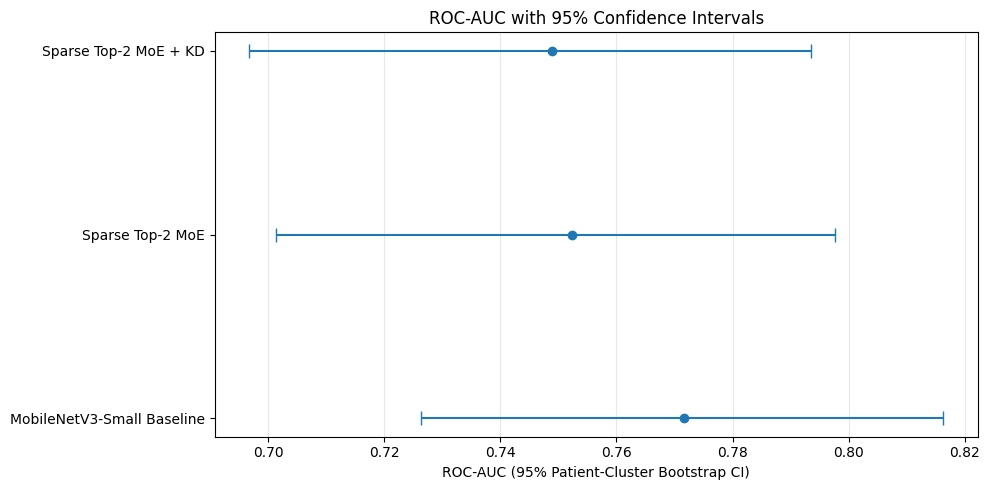

Saved: /content/drive/MyDrive/Research/outputs/efficiency_and_statistical_comparison/statistical_analysis/figures/student_roc_auc_bootstrap_ci.png


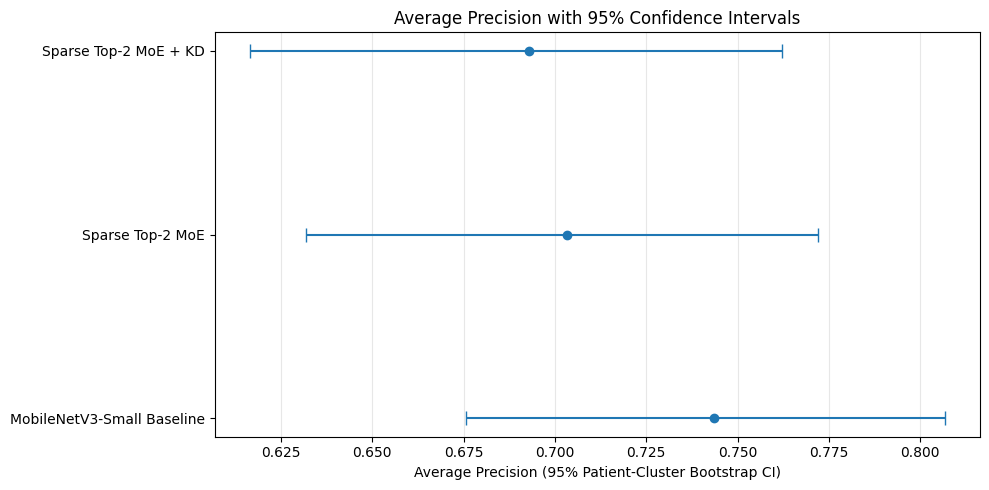

Saved: /content/drive/MyDrive/Research/outputs/efficiency_and_statistical_comparison/statistical_analysis/figures/student_average_precision_bootstrap_ci.png


In [110]:
ROC_AUC_CI_FIGURE_PATH = (
    STATISTICAL_FIGURE_DIR
    / "student_roc_auc_bootstrap_ci.png"
)

AP_CI_FIGURE_PATH = (
    STATISTICAL_FIGURE_DIR
    / "student_average_precision_bootstrap_ci.png"
)


plot_model_confidence_intervals(
    confidence_interval_dataframe=(
        bootstrap_ci_dataframe
    ),
    metric_name="roc_auc",
    metric_display_name="ROC-AUC",
    output_path=(
        ROC_AUC_CI_FIGURE_PATH
    ),
)

plot_model_confidence_intervals(
    confidence_interval_dataframe=(
        bootstrap_ci_dataframe
    ),
    metric_name=(
        "average_precision"
    ),
    metric_display_name=(
        "Average Precision"
    ),
    output_path=(
        AP_CI_FIGURE_PATH
    ),
)

## **Forest Plot of the ROC-AUC Difference**

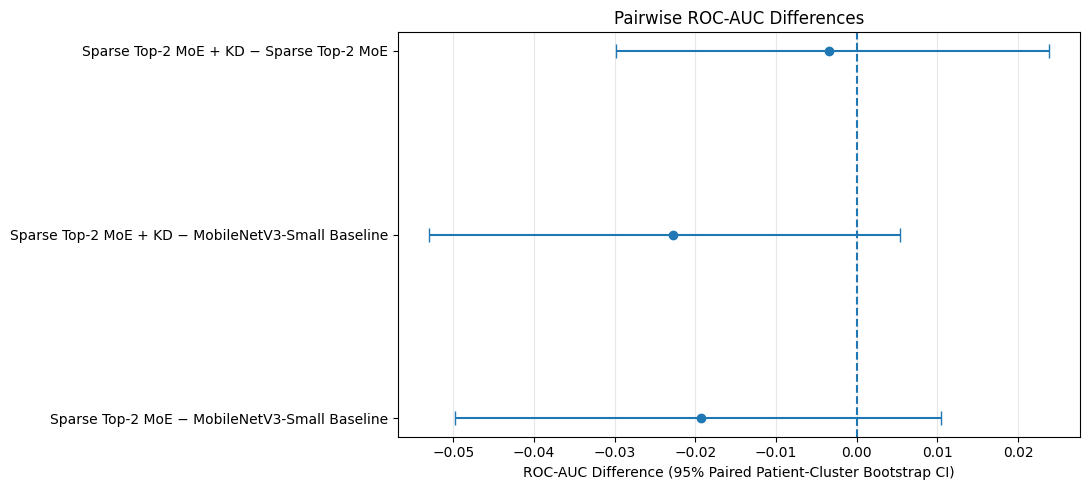

Saved: /content/drive/MyDrive/Research/outputs/efficiency_and_statistical_comparison/statistical_analysis/figures/pairwise_roc_auc_difference_ci.png


In [111]:
roc_difference_dataframe = (
    paired_bootstrap_difference_dataframe[
        paired_bootstrap_difference_dataframe[
            "metric"
        ]
        == "roc_auc"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


y_positions = np.arange(
    len(
        roc_difference_dataframe
    )
)


observed_differences = (
    roc_difference_dataframe[
        "observed_difference"
    ].to_numpy()
)


lower_errors = (
    observed_differences
    -
    roc_difference_dataframe[
        "ci_lower"
    ].to_numpy()
)

upper_errors = (
    roc_difference_dataframe[
        "ci_upper"
    ].to_numpy()
    -
    observed_differences
)


plt.figure(
    figsize=(11, 5)
)

plt.errorbar(
    observed_differences,
    y_positions,
    xerr=np.vstack(
        [
            lower_errors,
            upper_errors,
        ]
    ),
    fmt="o",
    capsize=5,
)

plt.axvline(
    0.0,
    linestyle="--",
)

plt.yticks(
    y_positions,
    roc_difference_dataframe[
        "comparison"
    ],
)

plt.xlabel(
    "ROC-AUC Difference "
    "(95% Paired Patient-Cluster Bootstrap CI)"
)

plt.title(
    "Pairwise ROC-AUC Differences"
)

plt.grid(
    axis="x",
    alpha=0.3,
)

plt.tight_layout()


ROC_AUC_DIFFERENCE_FIGURE_PATH = (
    STATISTICAL_FIGURE_DIR
    / "pairwise_roc_auc_difference_ci.png"
)


plt.savefig(
    ROC_AUC_DIFFERENCE_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print(
    "Saved:",
    ROC_AUC_DIFFERENCE_FIGURE_PATH,
)

## **Save All Statistical Results**

In [112]:
POINT_ESTIMATE_PATH = (
    STATISTICAL_TABLE_DIR
    / "student_point_estimates.csv"
)

BOOTSTRAP_RAW_PATH = (
    STATISTICAL_TABLE_DIR
    / "patient_cluster_bootstrap_raw.csv"
)

BOOTSTRAP_CI_PATH = (
    STATISTICAL_TABLE_DIR
    / "patient_cluster_bootstrap_confidence_intervals.csv"
)

PAIRED_BOOTSTRAP_DIFFERENCE_PATH = (
    STATISTICAL_TABLE_DIR
    / "paired_bootstrap_model_differences.csv"
)

PERMUTATION_RESULT_PATH = (
    STATISTICAL_TABLE_DIR
    / "patient_cluster_permutation_tests.csv"
)

FINAL_STATISTICAL_COMPARISON_PATH = (
    STATISTICAL_TABLE_DIR
    / "final_pairwise_statistical_comparison.csv"
)

ALIGNED_PREDICTION_PATH = (
    STATISTICAL_TABLE_DIR
    / "aligned_student_validation_predictions.csv"
)


point_estimate_dataframe.to_csv(
    POINT_ESTIMATE_PATH,
    index=False,
)

bootstrap_result_dataframe.to_csv(
    BOOTSTRAP_RAW_PATH,
    index=False,
)

bootstrap_ci_dataframe.to_csv(
    BOOTSTRAP_CI_PATH,
    index=False,
)

paired_bootstrap_difference_dataframe.to_csv(
    PAIRED_BOOTSTRAP_DIFFERENCE_PATH,
    index=False,
)

permutation_result_dataframe.to_csv(
    PERMUTATION_RESULT_PATH,
    index=False,
)

final_statistical_comparison_dataframe.to_csv(
    FINAL_STATISTICAL_COMPARISON_PATH,
    index=False,
)

statistical_prediction_dataframe.to_csv(
    ALIGNED_PREDICTION_PATH,
    index=False,
)


statistical_configuration = {
    "resampling_unit": "patient",
    "number_of_images": int(
        len(
            statistical_prediction_dataframe
        )
    ),
    "number_of_patients": int(
        len(
            unique_patient_ids
        )
    ),
    "bootstrap_iterations": int(
        NUMBER_OF_BOOTSTRAP_ITERATIONS
    ),
    "confidence_level": float(
        CONFIDENCE_LEVEL
    ),
    "permutation_iterations": int(
        NUMBER_OF_PERMUTATIONS
    ),
    "multiple_comparison_correction": (
        "Holm correction within each metric"
    ),
    "thresholds": {
        model_name: float(
            model_config[
                "threshold"
            ]
        )
        for model_name, model_config
        in STATISTICAL_MODELS.items()
    },
}


STATISTICAL_CONFIGURATION_PATH = (
    STATISTICAL_OUTPUT_DIR
    / "statistical_configuration.json"
)


with open(
    STATISTICAL_CONFIGURATION_PATH,
    "w",
    encoding="utf-8",
) as json_file:
    json.dump(
        statistical_configuration,
        json_file,
        indent=4,
    )


print(
    "Saved point estimates:",
    POINT_ESTIMATE_PATH,
)

print(
    "Saved bootstrap confidence intervals:",
    BOOTSTRAP_CI_PATH,
)

print(
    "Saved final statistical tests:",
    FINAL_STATISTICAL_COMPARISON_PATH,
)

print(
    "Saved configuration:",
    STATISTICAL_CONFIGURATION_PATH,
)

print(
    "Internal statistical analysis completed."
)

Saved point estimates: /content/drive/MyDrive/Research/outputs/efficiency_and_statistical_comparison/statistical_analysis/tables/student_point_estimates.csv
Saved bootstrap confidence intervals: /content/drive/MyDrive/Research/outputs/efficiency_and_statistical_comparison/statistical_analysis/tables/patient_cluster_bootstrap_confidence_intervals.csv
Saved final statistical tests: /content/drive/MyDrive/Research/outputs/efficiency_and_statistical_comparison/statistical_analysis/tables/final_pairwise_statistical_comparison.csv
Saved configuration: /content/drive/MyDrive/Research/outputs/efficiency_and_statistical_comparison/statistical_analysis/statistical_configuration.json
Internal statistical analysis completed.


# **FINAL SUMMARY**

## **Creating a Table of Wide Confidence Intervals**

In [113]:
SUMMARY_CI_METRICS = [
    "roc_auc",
    "average_precision",
    "sensitivity",
    "specificity",
    "f1",
]


summary_ci_dataframe = (
    bootstrap_ci_dataframe[
        bootstrap_ci_dataframe[
            "metric"
        ].isin(
            SUMMARY_CI_METRICS
        )
    ]
    .pivot(
        index="model",
        columns="metric",
        values=[
            "ci_lower",
            "ci_upper",
        ],
    )
)


summary_ci_dataframe.columns = [
    f"{metric_name}_{bound_name}"
    for bound_name, metric_name
    in summary_ci_dataframe.columns
]


summary_ci_dataframe = (
    summary_ci_dataframe
    .reset_index()
)


display(
    summary_ci_dataframe.round(4)
)

,model,average_precision_ci_lower,f1_ci_lower,roc_auc_ci_lower,sensitivity_ci_lower,specificity_ci_lower,average_precision_ci_upper,f1_ci_upper,roc_auc_ci_upper,sensitivity_ci_upper,specificity_ci_upper
0,MobileNetV3-Small Baseline,0.6756,0.6008,0.7263,0.5620,0.7126,0.8068,0.7140,0.8163,0.6885,0.8207
1,Sparse Top-2 MoE,0.6318,0.6539,0.7013,0.7399,0.5417,0.7720,0.7500,0.7976,0.8400,0.6762
2,Sparse Top-2 MoE + KD,0.6164,0.6594,0.6968,0.8059,0.4618,0.7620,0.7559,0.7936,0.8920,0.6079


## **Combining performance and efficiency**

In [114]:
student_batch1_latency = (
    repeated_latency_summary[
        repeated_latency_summary[
            "batch_size"
        ]
        == 1
    ][
        [
            "model",
            "final_median_latency_per_image_ms",
            "final_throughput_images_per_second",
            "latency_iqr_ms",
            "between_round_std_ms",
        ]
    ]
    .copy()
)


student_batch1_memory = (
    total_peak_memory_dataframe[
        total_peak_memory_dataframe[
            "batch_size"
        ]
        == 1
    ][
        [
            "model",
            "total_peak_from_background_mb",
            "forward_incremental_peak_mb",
        ]
    ]
    .copy()
)


final_student_performance_efficiency = (
    point_estimate_dataframe
    .merge(
        summary_ci_dataframe,
        on="model",
        how="left",
        validate="one_to_one",
    )
    .merge(
        static_efficiency_dataframe[
            [
                "model",
                "parameters",
                "parameter_memory_fp32_mb",
                "stripped_checkpoint_mb",
                "estimated_gmacs",
                "estimated_gflops",
            ]
        ],
        on="model",
        how="left",
        validate="one_to_one",
    )
    .merge(
        student_batch1_latency,
        on="model",
        how="left",
        validate="one_to_one",
    )
    .merge(
        student_batch1_memory,
        on="model",
        how="left",
        validate="one_to_one",
    )
)


display(
    final_student_performance_efficiency
    .round(4)
)

,model,threshold,roc_auc,pr_auc,average_precision,accuracy,balanced_accuracy,precision,sensitivity,specificity,...,parameter_memory_fp32_mb,stripped_checkpoint_mb,estimated_gmacs,estimated_gflops,final_median_latency_per_image_ms,final_throughput_images_per_second,latency_iqr_ms,between_round_std_ms,total_peak_from_background_mb,forward_incremental_peak_mb
0,MobileNetV3-Small Baseline,0.5166,0.7716,0.7420,0.7435,0.7021,0.6968,0.6977,0.6272,0.7665,...,3.5385,3.6607,0.1977,0.3954,6.1353,162.9905,0.1614,0.7495,8.7241,3.125
1,Sparse Top-2 MoE,0.3496,0.7524,0.7025,0.7034,0.6940,0.7009,0.6359,0.7909,0.6108,...,4.6662,4.7905,0.1980,0.3960,7.1969,138.9491,0.0507,0.0821,9.8618,3.125
2,Sparse Top-2 MoE + KD,0.2530,0.7489,0.6917,0.6928,0.6795,0.6916,0.6100,0.8502,0.5329,...,4.6662,4.7925,0.1980,0.3960,7.2825,137.3156,0.5473,0.7563,9.8618,3.125


## **Calculating the change relative to the baseline**

In [115]:
baseline_summary_row = (
    final_student_performance_efficiency[
        final_student_performance_efficiency[
            "model"
        ]
        == "MobileNetV3-Small Baseline"
    ]
    .iloc[0]
)


final_student_performance_efficiency[
    "parameter_change_vs_baseline_pct"
] = (
    (
        final_student_performance_efficiency[
            "parameters"
        ]
        -
        baseline_summary_row[
            "parameters"
        ]
    )
    /
    baseline_summary_row[
        "parameters"
    ]
    * 100.0
)


final_student_performance_efficiency[
    "latency_change_vs_baseline_pct"
] = (
    (
        final_student_performance_efficiency[
            "final_median_latency_per_image_ms"
        ]
        -
        baseline_summary_row[
            "final_median_latency_per_image_ms"
        ]
    )
    /
    baseline_summary_row[
        "final_median_latency_per_image_ms"
    ]
    * 100.0
)


final_student_performance_efficiency[
    "peak_memory_change_vs_baseline_pct"
] = (
    (
        final_student_performance_efficiency[
            "total_peak_from_background_mb"
        ]
        -
        baseline_summary_row[
            "total_peak_from_background_mb"
        ]
    )
    /
    baseline_summary_row[
        "total_peak_from_background_mb"
    ]
    * 100.0
)


for metric_name in [
    "roc_auc",
    "average_precision",
    "balanced_accuracy",
    "sensitivity",
    "specificity",
    "f1",
]:
    final_student_performance_efficiency[
        f"{metric_name}_difference_vs_baseline"
    ] = (
        final_student_performance_efficiency[
            metric_name
        ]
        -
        baseline_summary_row[
            metric_name
        ]
    )

## **Main summary table**

In [116]:
final_student_summary_table = (
    final_student_performance_efficiency[
        [
            "model",
            "parameters",
            "estimated_gmacs",
            "stripped_checkpoint_mb",
            "final_median_latency_per_image_ms",
            "final_throughput_images_per_second",
            "total_peak_from_background_mb",
            "roc_auc",
            "roc_auc_ci_lower",
            "roc_auc_ci_upper",
            "average_precision",
            "average_precision_ci_lower",
            "average_precision_ci_upper",
            "balanced_accuracy",
            "sensitivity",
            "sensitivity_ci_lower",
            "sensitivity_ci_upper",
            "specificity",
            "specificity_ci_lower",
            "specificity_ci_upper",
            "f1",
            "f1_ci_lower",
            "f1_ci_upper",
            "parameter_change_vs_baseline_pct",
            "latency_change_vs_baseline_pct",
            "peak_memory_change_vs_baseline_pct",
        ]
    ]
)


display(
    final_student_summary_table.round(4)
)

,model,parameters,estimated_gmacs,stripped_checkpoint_mb,final_median_latency_per_image_ms,final_throughput_images_per_second,total_peak_from_background_mb,roc_auc,roc_auc_ci_lower,roc_auc_ci_upper,...,sensitivity_ci_upper,specificity,specificity_ci_lower,specificity_ci_upper,f1,f1_ci_lower,f1_ci_upper,parameter_change_vs_baseline_pct,latency_change_vs_baseline_pct,peak_memory_change_vs_baseline_pct
0,MobileNetV3-Small Baseline,927585,0.1977,3.6607,6.1353,162.9905,8.7241,0.7716,0.7263,0.8163,...,0.6885,0.7665,0.7126,0.8207,0.6606,0.6008,0.7140,0.00,0.0000,0.0000
1,Sparse Top-2 MoE,1223206,0.1980,4.7905,7.1969,138.9491,9.8618,0.7524,0.7013,0.7976,...,0.8400,0.6108,0.5417,0.6762,0.7050,0.6539,0.7500,31.87,17.3023,13.0408
2,Sparse Top-2 MoE + KD,1223206,0.1980,4.7925,7.2825,137.3156,9.8618,0.7489,0.6968,0.7936,...,0.8920,0.5329,0.4618,0.6079,0.7103,0.6594,0.7559,31.87,18.6977,13.0408


## **Plot the ROC-AUC versus latency trade-off**

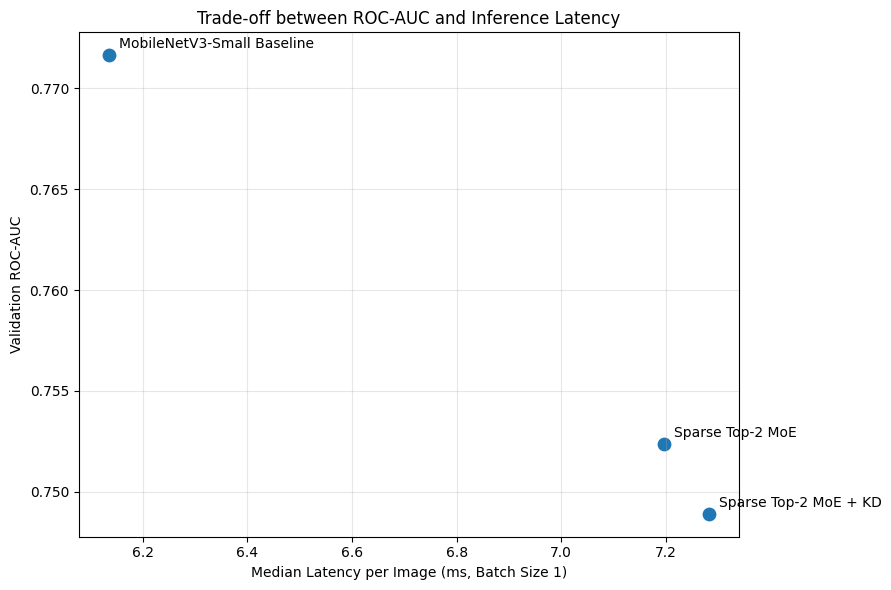

Saved: /content/drive/MyDrive/Research/outputs/efficiency_and_statistical_comparison/statistical_analysis/figures/student_roc_auc_latency_tradeoff.png


In [117]:
ROC_AUC_LATENCY_FIGURE_PATH = (
    STATISTICAL_FIGURE_DIR
    / "student_roc_auc_latency_tradeoff.png"
)


plt.figure(
    figsize=(9, 6)
)


plt.scatter(
    final_student_performance_efficiency[
        "final_median_latency_per_image_ms"
    ],
    final_student_performance_efficiency[
        "roc_auc"
    ],
    s=80,
)


for _, row in (
    final_student_performance_efficiency
    .iterrows()
):
    plt.annotate(
        row["model"],
        (
            row[
                "final_median_latency_per_image_ms"
            ],
            row["roc_auc"],
        ),
        xytext=(7, 5),
        textcoords="offset points",
    )


plt.xlabel(
    "Median Latency per Image "
    "(ms, Batch Size 1)"
)

plt.ylabel(
    "Validation ROC-AUC"
)

plt.title(
    "Trade-off between ROC-AUC "
    "and Inference Latency"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    ROC_AUC_LATENCY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print(
    "Saved:",
    ROC_AUC_LATENCY_FIGURE_PATH,
)

## **Plot the trade-off between sensitivity and specificity**

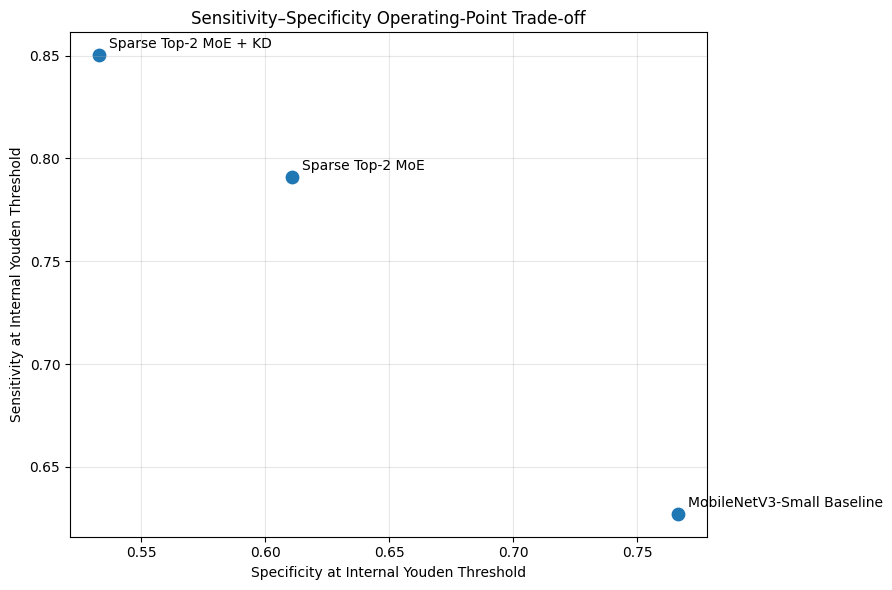

Saved: /content/drive/MyDrive/Research/outputs/efficiency_and_statistical_comparison/statistical_analysis/figures/student_sensitivity_specificity_tradeoff.png


In [118]:
SENSITIVITY_SPECIFICITY_FIGURE_PATH = (
    STATISTICAL_FIGURE_DIR
    / "student_sensitivity_specificity_tradeoff.png"
)


plt.figure(
    figsize=(9, 6)
)


plt.scatter(
    final_student_performance_efficiency[
        "specificity"
    ],
    final_student_performance_efficiency[
        "sensitivity"
    ],
    s=80,
)


for _, row in (
    final_student_performance_efficiency
    .iterrows()
):
    plt.annotate(
        row["model"],
        (
            row["specificity"],
            row["sensitivity"],
        ),
        xytext=(7, 5),
        textcoords="offset points",
    )


plt.xlabel(
    "Specificity at Internal "
    "Youden Threshold"
)

plt.ylabel(
    "Sensitivity at Internal "
    "Youden Threshold"
)

plt.title(
    "Sensitivity–Specificity "
    "Operating-Point Trade-off"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    SENSITIVITY_SPECIFICITY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print(
    "Saved:",
    SENSITIVITY_SPECIFICITY_FIGURE_PATH,
)

## **Save the final summary**

In [119]:
FINAL_STUDENT_SUMMARY_PATH = (
    PROFILING_TABLE_DIR
    / "final_student_performance_efficiency_summary.csv"
)


FINAL_STATISTICAL_SIGNIFICANCE_PATH = (
    PROFILING_TABLE_DIR
    / "final_student_pairwise_significance_summary.csv"
)


final_student_summary_table.to_csv(
    FINAL_STUDENT_SUMMARY_PATH,
    index=False,
)


final_statistical_comparison_dataframe.to_csv(
    FINAL_STATISTICAL_SIGNIFICANCE_PATH,
    index=False,
)


notebook_06_summary = {
    "validation_images": int(
        len(
            statistical_prediction_dataframe
        )
    ),

    "validation_patients": int(
        statistical_prediction_dataframe[
            "patient_id"
        ].nunique()
    ),

    "bootstrap_iterations": int(
        NUMBER_OF_BOOTSTRAP_ITERATIONS
    ),

    "permutation_iterations": int(
        NUMBER_OF_PERMUTATIONS
    ),

    "best_numeric_roc_auc_model": (
        point_estimate_dataframe
        .sort_values(
            "roc_auc",
            ascending=False,
        )
        .iloc[0][
            "model"
        ]
    ),

    "highest_sensitivity_model": (
        point_estimate_dataframe
        .sort_values(
            "sensitivity",
            ascending=False,
        )
        .iloc[0][
            "model"
        ]
    ),

    "highest_specificity_model": (
        point_estimate_dataframe
        .sort_values(
            "specificity",
            ascending=False,
        )
        .iloc[0][
            "model"
        ]
    ),

    "roc_auc_pairwise_significant": False,

    "main_statistical_interpretation": (
        "MoE and KD did not significantly "
        "improve ROC-AUC, Average Precision, "
        "or balanced accuracy. They increased "
        "sensitivity while reducing specificity "
        "at their internal Youden operating points."
    ),
}


NOTEBOOK_06_SUMMARY_PATH = (
    PROFILING_OUTPUT_DIR
    / "notebook_06_summary.json"
)


with open(
    NOTEBOOK_06_SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as json_file:
    json.dump(
        notebook_06_summary,
        json_file,
        indent=4,
    )


print(
    "Saved final student summary:",
    FINAL_STUDENT_SUMMARY_PATH,
)

print(
    "Saved pairwise significance table:",
    FINAL_STATISTICAL_SIGNIFICANCE_PATH,
)

print(
    "Saved Notebook 06 summary:",
    NOTEBOOK_06_SUMMARY_PATH,
)

print(
    "Notebook 06 completed successfully."
)

Saved final student summary: /content/drive/MyDrive/Research/outputs/efficiency_and_statistical_comparison/tables/final_student_performance_efficiency_summary.csv
Saved pairwise significance table: /content/drive/MyDrive/Research/outputs/efficiency_and_statistical_comparison/tables/final_student_pairwise_significance_summary.csv
Saved Notebook 06 summary: /content/drive/MyDrive/Research/outputs/efficiency_and_statistical_comparison/notebook_06_summary.json
Notebook 06 completed successfully.
